# CNN Multi Dim Analysis

### Imports, constants, loading datasets and results

In [1]:
%load_ext autoreload
%autoreload 2

import gc
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
from plots import (
    get_all_base_plots,
    plot_dope_interp_scores,
    plot_dope_mesh,
    plot_pairwise_rmsd,
)
from torch import Tensor
from utils import (
    TrainConfig,
    composite_loss,
    get_all_stats,
    make_hyperlatent_mlp_mas,
    make_hyperlatent_pca_mas,
    make_hyperlatent_umap_mas,
)

sys.path.insert(0, os.path.join(os.path.abspath(os.pardir), "src"))
from molearn.analysis import MolearnAnalysis
from molearn.analysis.plot import *
from molearn.analysis.plot import plot_rmsd_hist
from molearn.data import PDBData
from molearn.models.CNN_autoencoder import AutoEncoder, ToND
from molearn.models.latent_autoencoder import LatentAutoencoder

# === loading datasets ==============================================

device: str = "cuda" if torch.cuda.is_available() else "cpu"
atoms: list[str] = ["N", "CA", "C", "O", "CB"]

with open("../data/full/data_statistics.json") as f:
    stats = json.load(f)

mean: float = stats["mean"]
std: float = stats["std"]

data_closed = PDBData(
    filename=["../data/full/murd_closed.pdb"],
    atoms=atoms,
    fix_terminal=True,
)
_: Tensor = data_closed.prepare_dataset(mean=mean, std=std)


data_open = PDBData(
    filename=["../data/full/murd_open.pdb"],
    atoms=atoms,
    fix_terminal=True,
)
_: Tensor = data_open.prepare_dataset(mean=mean, std=std)

data_both = PDBData(
    filename=["../data/full/murd_both.pdb"],
    atoms=atoms,
    fix_terminal=True,
)
_: Tensor = data_both.prepare_dataset(mean=mean, std=std)

data_test = PDBData(
    filename=["../data/full/murd_test.pdb"],
    atoms=atoms,
    fix_terminal=True,
)

_: Tensor = data_test.prepare_dataset(mean=mean, std=std)

data_5a5e = PDBData(
    filename=["../data/crystals_aligned/5A5E.pdb"],
    atoms=atoms,
    fix_terminal=True,
)

_: Tensor = data_5a5e.prepare_dataset(mean=mean, std=std)

data_5a5f = PDBData(
    filename=["../data/crystals_aligned/5A5F.pdb"],
    atoms=atoms,
    fix_terminal=True,
)

_: Tensor = data_5a5f.prepare_dataset(mean=mean, std=std)

# === constants =========================================================

BASE_PATH: str = r"../results/11-feb-2026-latent-dim-physics"
RUNS: list[int] = list(range(1, 16))
ALL_VARS: list[int] = list(range(2, 21))
N_ATOMS: int = 2145
RANDOM_STATE: int = 42
CLOSED_COLOR: str = "#AFC2DC"
OPEN_COLOR: str = "#FDBFCA"
BOTH_COLOR: str = "#FDBFCA"
TEST_COLOR: str = "#7FB069"
N_SAMPLES: int = 60
REFINE: bool = True
TRUNCATE_AT: int = -23000
KEYS_ALL = ("train_open", "train_closed", "train_both", "test_trans")
KEYS_BOTH = ("train_both", "test_trans")
KEYS_NO_BOTH = ("train_open", "train_closed", "test_trans")

# === loading results =========================================================

PlotData = list[tuple[str, ...]]


log_dfs: dict[int, dict[int, pd.DataFrame]]
min_valid_losses: dict[int, dict[int, float]]
min_valid_mse_losses: dict[int, dict[int, float]]
models: dict[int, dict[int, AutoEncoder]]
MAs: dict[int, dict[int, MolearnAnalysis]]

log_dfs, min_valid_losses, min_valid_mse_losses, models, MAs = (
    {t: {} for t in RUNS} for _ in range(5)
)


for t in RUNS:
    for var in ALL_VARS:
        log_dfs[t][var] = pd.read_csv(Path(f"{BASE_PATH}/{t}/{var}/log.dat"))
        best_epoch: int = log_dfs[t][var]["valid_loss"].idxmin()  # type: ignore[assignment]
        min_valid_losses[t][var] = min(log_dfs[t][var].valid_loss)
        min_valid_mse_losses[t][var] = min(log_dfs[t][var].valid_mse_loss)

        checkpoint_path: Path = Path(f"{BASE_PATH}/{t}/{var}/checkpoint_converged.ckpt")
        checkpoint: dict = torch.load(
            checkpoint_path, map_location=device, weights_only=False
        )

        model: AutoEncoder = AutoEncoder(n_atoms=N_ATOMS, latent_dim=var)
        model.load_state_dict(checkpoint["model_state_dict"])

        models[t][var] = model

        MA: MolearnAnalysis = MolearnAnalysis()
        MA.batch_size = 16
        MA.processes = 4

        MA.set_dataset(data=data_open, key="train_open")
        MA.set_dataset(data=data_closed, key="train_closed")
        MA.set_dataset(data=data_both, key="train_both")
        MA.set_dataset(data=data_test, key="test_trans")
        MA.set_dataset(data=data_5a5e, key="5A5E")
        MA.set_dataset(data=data_5a5f, key="5A5F")

        MA.set_network(models[t][var])

        MAs[t][var] = MA

Using pre-computed mean: 17.09642555407783, std: 23.559262743825876
Dataset shape: torch.Size([2000, 2145, 3])
Using pre-computed mean: 17.09642555407783, std: 23.559262743825876
Dataset shape: torch.Size([2000, 2145, 3])
Using pre-computed mean: 17.09642555407783, std: 23.559262743825876
Dataset shape: torch.Size([4000, 2145, 3])
Using pre-computed mean: 17.09642555407783, std: 23.559262743825876
Dataset shape: torch.Size([1600, 2145, 3])
Using pre-computed mean: 17.09642555407783, std: 23.559262743825876
Dataset shape: torch.Size([1, 2145, 3])
Using pre-computed mean: 17.09642555407783, std: 23.559262743825876
Dataset shape: torch.Size([1, 2145, 3])


## Base plots

### All plots

encoding train_both: 250it [00:01, 210.21it/s]
Decoding train_both: 250it [00:01, 131.60it/s]
encoding test_trans: 100it [00:00, 217.92it/s]
Decoding test_trans: 100it [00:00, 137.92it/s]


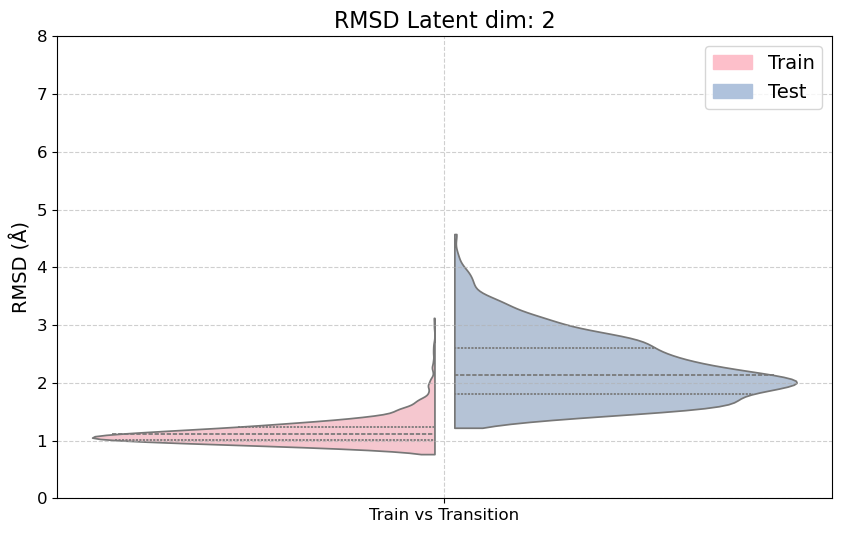

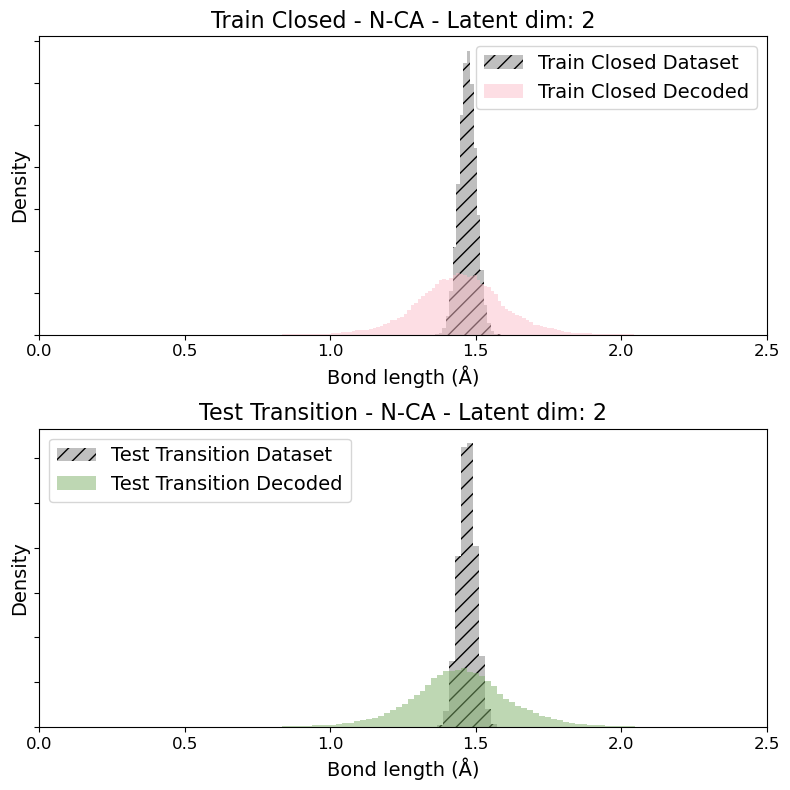

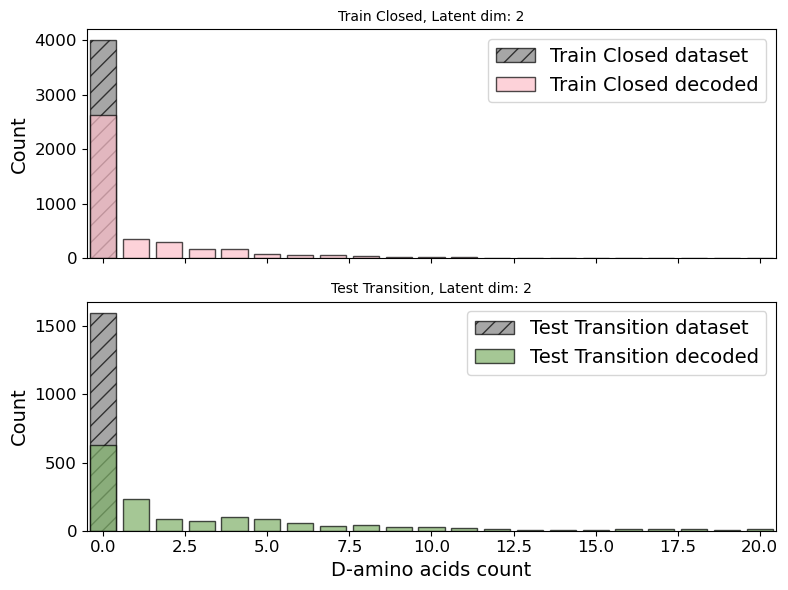

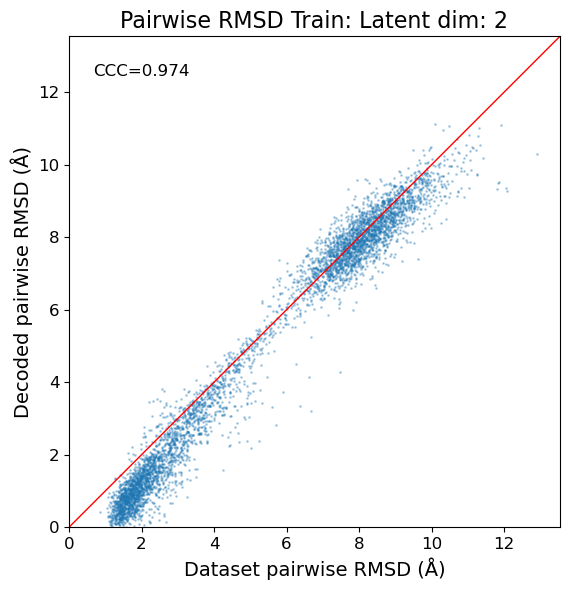

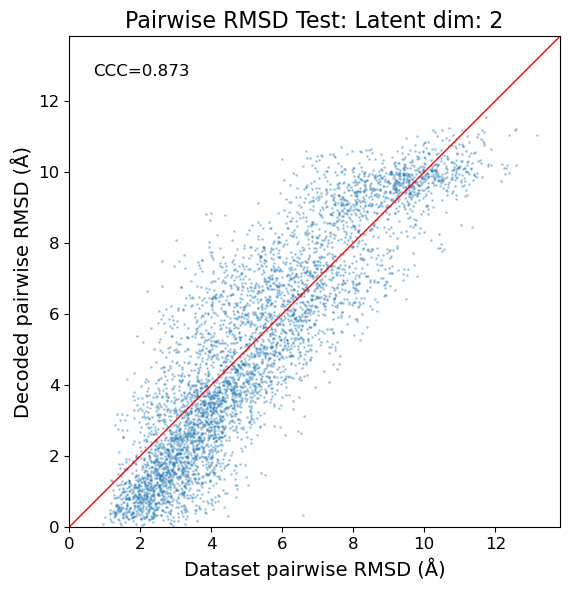

encoding train_both: 250it [00:00, 266.95it/s]
Decoding train_both: 250it [00:01, 152.41it/s]
encoding test_trans: 100it [00:00, 241.89it/s]
Decoding test_trans: 100it [00:00, 151.70it/s]


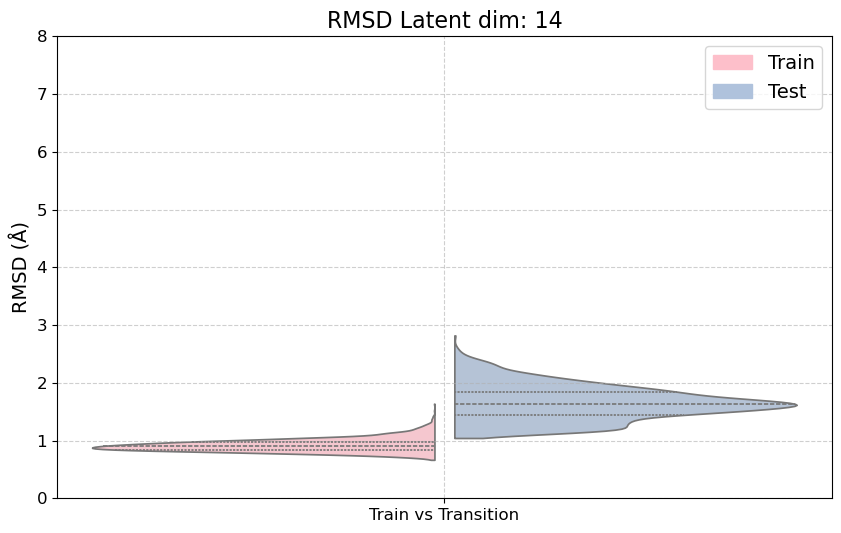

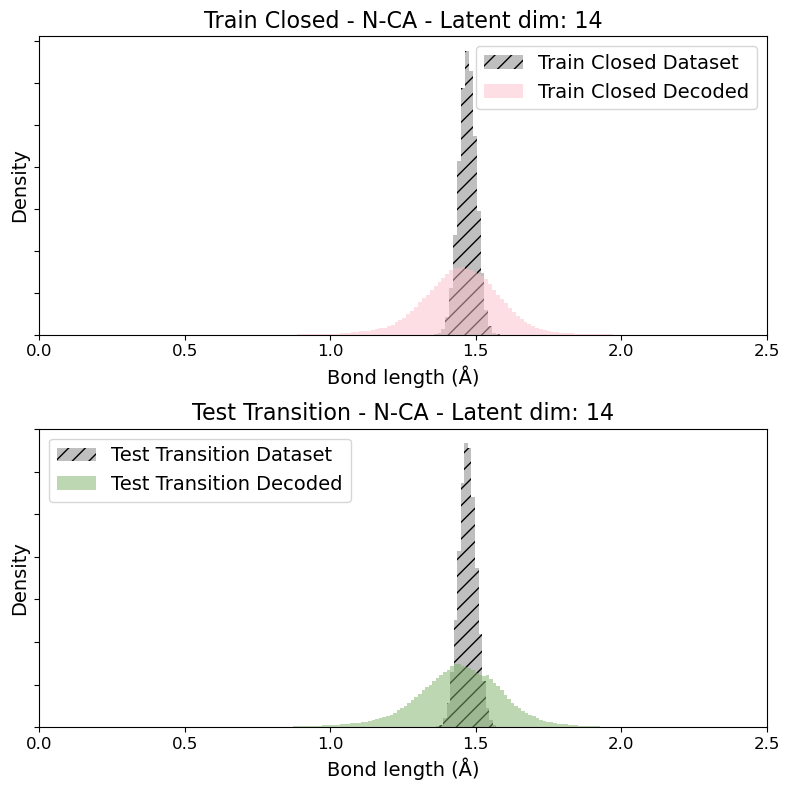

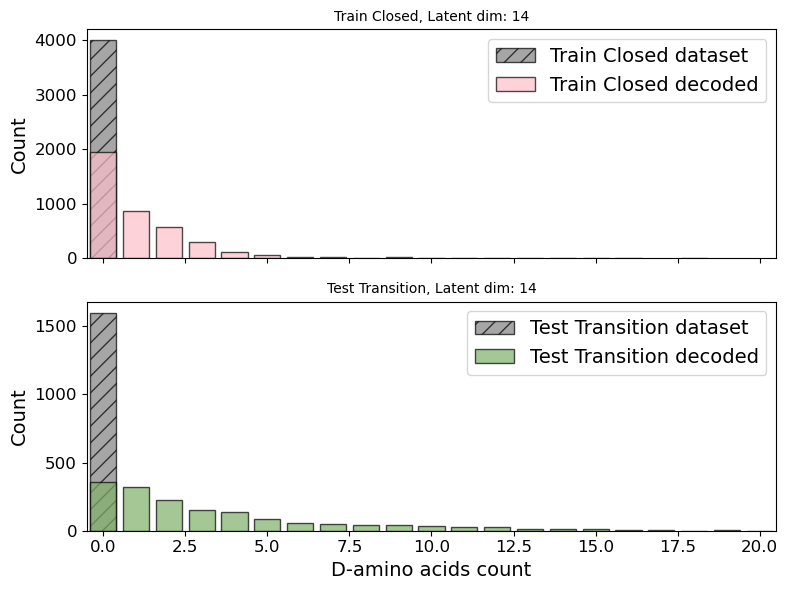

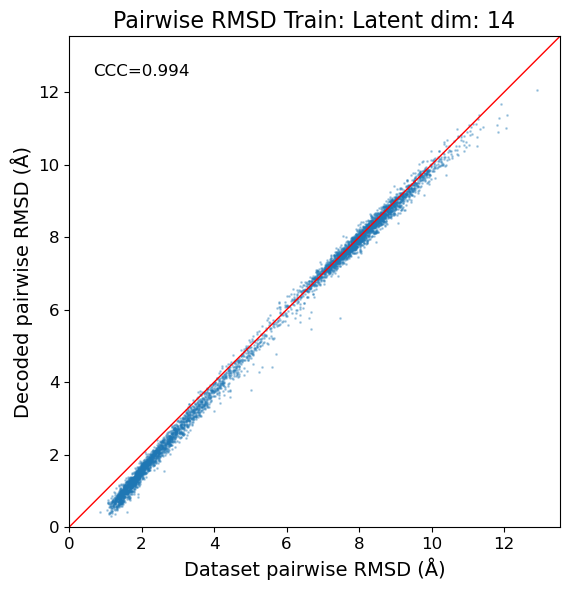

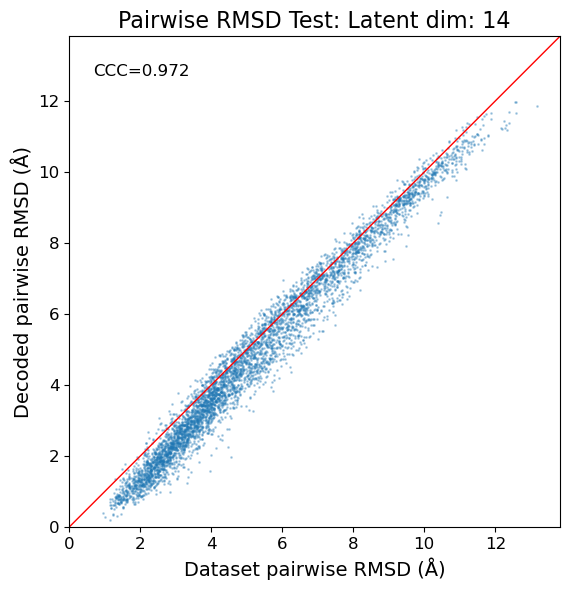

In [ ]:
for run, var, folder in [[1, 2, "baseline"], [3, 14, "target"]]:
    get_all_base_plots(
        ma=MAs[run][var],
        keys=KEYS_ALL,
        plot_data=plot_data,
        latent_dim=var,
        run=run,
        save_dir=f"../{folder}",
    )

### All stats calculation (and test)

In [ ]:
KEYS = ["train_both"]

plot_data: PlotData = [
    ("train_both", "Train Both", BOTH_COLOR),
    ("test_trans", "Test Transition", TEST_COLOR),
]

for run in [[15]]:
    save_dir = Path(f"../statistics/all_stats_both_r{run[0]}")
    df = get_all_stats(
        mas=MAs,
        varis=ALL_VARS,
        runs=run,
        keys=KEYS,
        random_state=RANDOM_STATE,
        save_dir=save_dir,
    )

encoding train_both: 250it [00:01, 204.39it/s]
Decoding train_both: 250it [00:02, 107.20it/s]
encoding train_both: 250it [00:00, 251.46it/s]
Decoding train_both: 250it [00:01, 154.45it/s]
encoding train_both: 250it [00:00, 298.33it/s]
Decoding train_both: 250it [00:00, 345.33it/s]
encoding train_both: 250it [00:00, 276.75it/s]
Decoding train_both: 250it [00:01, 146.64it/s]
encoding train_both: 250it [00:00, 277.71it/s]
Decoding train_both: 250it [00:01, 163.56it/s]
encoding train_both: 250it [00:00, 277.66it/s]
Decoding train_both: 250it [00:01, 172.44it/s]
encoding train_both: 250it [00:00, 250.37it/s]
Decoding train_both: 250it [00:01, 144.06it/s]
encoding train_both: 250it [00:00, 289.97it/s]
Decoding train_both: 250it [00:00, 343.27it/s] 
encoding train_both: 250it [00:01, 245.50it/s]
Decoding train_both: 250it [00:01, 135.00it/s]
encoding train_both: 250it [00:00, 256.62it/s]
Decoding train_both: 250it [00:01, 147.36it/s]
encoding train_both: 250it [00:00, 288.69it/s]
Decoding tra

### Model architecture and shapes

In [13]:
def print_encoder_shapes(model: AutoEncoder, n_atoms: int) -> None:
    """Print the shape at each stage of the encoder"""
    # Create dummy input: (batch=1, atoms=n_atoms, coords=3)
    x: Tensor = torch.randn(1, n_atoms, 3)

    # Permute to (batch, 3, atoms) as encoder expects
    x = x.permute(0, 2, 1)
    print(f"Input shape: {x.shape}")

    for i, m in enumerate(model.encoder):
        if isinstance(m, ToND):
            # ToND expects unsqueezed input
            x_unsqueezed: Tensor = x.unsqueeze(-1)
            print(f"  After unsqueeze(-1): {x_unsqueezed.shape}")
            x = m(x_unsqueezed)
        else:
            x = m(x)

        # Print shape after certain layer types
        print(f"Layer {i} ({m.__class__.__name__}): {x.shape}")

    print(f"\nFinal latent shape: {x.shape}")


# Test with your model

var: int = 2
run: int = 1

print("=" * 60)
print(f"ENCODER FORWARD PASS - latent_dim={var}")
print("=" * 60)
print_encoder_shapes(models[run][var], n_atoms=N_ATOMS)

ENCODER FORWARD PASS - latent_dim=2
Input shape: torch.Size([1, 3, 2145])
Layer 0 (Conv1d): torch.Size([1, 32, 1072])
Layer 1 (BatchNorm1d): torch.Size([1, 32, 1072])
Layer 2 (ReLU): torch.Size([1, 32, 1072])
Layer 3 (Conv1d): torch.Size([1, 48, 536])
Layer 4 (BatchNorm1d): torch.Size([1, 48, 536])
Layer 5 (ReLU): torch.Size([1, 48, 536])
Layer 6 (Conv1d): torch.Size([1, 72, 268])
Layer 7 (BatchNorm1d): torch.Size([1, 72, 268])
Layer 8 (ReLU): torch.Size([1, 72, 268])
Layer 9 (Conv1d): torch.Size([1, 108, 134])
Layer 10 (BatchNorm1d): torch.Size([1, 108, 134])
Layer 11 (ReLU): torch.Size([1, 108, 134])
Layer 12 (Conv1d): torch.Size([1, 162, 67])
Layer 13 (BatchNorm1d): torch.Size([1, 162, 67])
Layer 14 (ReLU): torch.Size([1, 162, 67])
Layer 15 (Conv1d): torch.Size([1, 1, 33])
  After unsqueeze(-1): torch.Size([1, 1, 33, 1])
Layer 16 (ToND): torch.Size([1, 2])

Final latent shape: torch.Size([1, 2])


In [11]:
def print_decoder_shapes(model: AutoEncoder, latent_dim: int) -> Tensor:
    """Print the shape at each stage of the decoder"""
    # Create dummy latent input: (batch=1, latent_dim)
    x: Tensor = torch.randn(1, latent_dim)
    print(f"Input latent shape: {x.shape}")

    for i, m in enumerate(model.decoder):
        x = m(x)

        # Print shape after certain layer types
        # if isinstance(m, (nn.Conv1d, nn.ConvTranspose1d, ToND, FromND)):
        print(f"Layer {i} ({m.__class__.__name__}): {x.shape}")

    print(f"\nFinal output shape: {x.shape}")
    return x


# Test with your model
var: int = 2
run: int = 1

print("=" * 60)
print(f"DECODER FORWARD PASS - latent_dim={var}")
print("=" * 60)
decoded: Tensor = print_decoder_shapes(models[run][var], var)
print(f"\nExpected atoms: {data_open.dataset.shape[1]}")
print(f"Decoder output atoms: {decoded.shape[2]}")
print(f"Difference: {decoded.shape[2] - data_open.dataset.shape[1]} atoms discarded")

DECODER FORWARD PASS - latent_dim=2
Input latent shape: torch.Size([1, 2])
Layer 0 (FromND): torch.Size([1, 1, 17])
Layer 1 (ConvTranspose1d): torch.Size([1, 243, 34])
Layer 2 (BatchNorm1d): torch.Size([1, 243, 34])
Layer 3 (ReLU): torch.Size([1, 243, 34])
Layer 4 (ConvTranspose1d): torch.Size([1, 162, 68])
Layer 5 (BatchNorm1d): torch.Size([1, 162, 68])
Layer 6 (ReLU): torch.Size([1, 162, 68])
Layer 7 (ConvTranspose1d): torch.Size([1, 108, 136])
Layer 8 (BatchNorm1d): torch.Size([1, 108, 136])
Layer 9 (ReLU): torch.Size([1, 108, 136])
Layer 10 (ConvTranspose1d): torch.Size([1, 72, 272])
Layer 11 (BatchNorm1d): torch.Size([1, 72, 272])
Layer 12 (ReLU): torch.Size([1, 72, 272])
Layer 13 (ConvTranspose1d): torch.Size([1, 48, 544])
Layer 14 (BatchNorm1d): torch.Size([1, 48, 544])
Layer 15 (ReLU): torch.Size([1, 48, 544])
Layer 16 (ConvTranspose1d): torch.Size([1, 32, 1088])
Layer 17 (BatchNorm1d): torch.Size([1, 32, 1088])
Layer 18 (ReLU): torch.Size([1, 32, 1088])
Layer 19 (ConvTranspose

### MSE Plots 

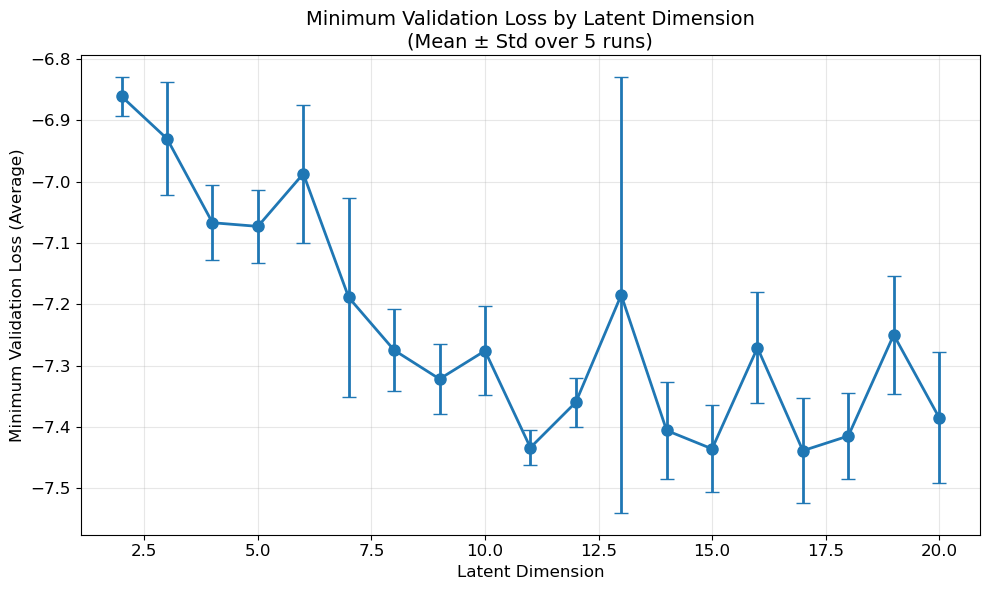

In [18]:
# Plot line graph of minimum validation losses (averaged over triplicates)

avg_valid_losses: dict[int, float] = {}
std_valid_losses: dict[int, float] = {}

for var in ALL_VARS:
    losses: list[float] = [min_valid_losses[t][var] for t in RUNS]
    avg_valid_losses[var] = float(np.mean(losses))
    std_valid_losses[var] = float(np.std(losses))

plt.figure(figsize=(10, 6))
plt.errorbar(
    list(avg_valid_losses.keys()),
    list(avg_valid_losses.values()),
    yerr=list(std_valid_losses.values()),
    marker="o",
    linewidth=2,
    markersize=8,
    capsize=5,
)
plt.xlabel("Latent Dimension", fontsize=12)
plt.ylabel("Minimum Validation Loss (Average)", fontsize=12)
plt.title(
    "Minimum Validation Loss by Latent Dimension\n(Mean ± Std over 5 runs)",
    fontsize=14,
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Model plots

#### Setup

In [11]:
median_models: list[list[int]] = []

for var in ALL_VARS:
    losses = [(min_valid_losses[t][var], t) for t in RUNS]
    losses.sort()
    median_run = losses[len(losses) // 2][1]
    median_models.append([median_run, var])

print(median_models)

plot_data: PlotData = [
    ("train_both", "Train Both", BOTH_COLOR),
    ("test_trans", "Test Transition", TEST_COLOR),
]

[[8, 2], [1, 3], [12, 4], [13, 5], [12, 6], [5, 7], [14, 8], [5, 9], [10, 10], [11, 11], [14, 12], [11, 13], [5, 14], [11, 15], [11, 16], [2, 17], [15, 18], [15, 19], [3, 20]]


#### RMSD Hist plot

Decoding train_both: 250it [00:01, 141.11it/s]
Decoding test_trans: 100it [00:00, 177.23it/s]


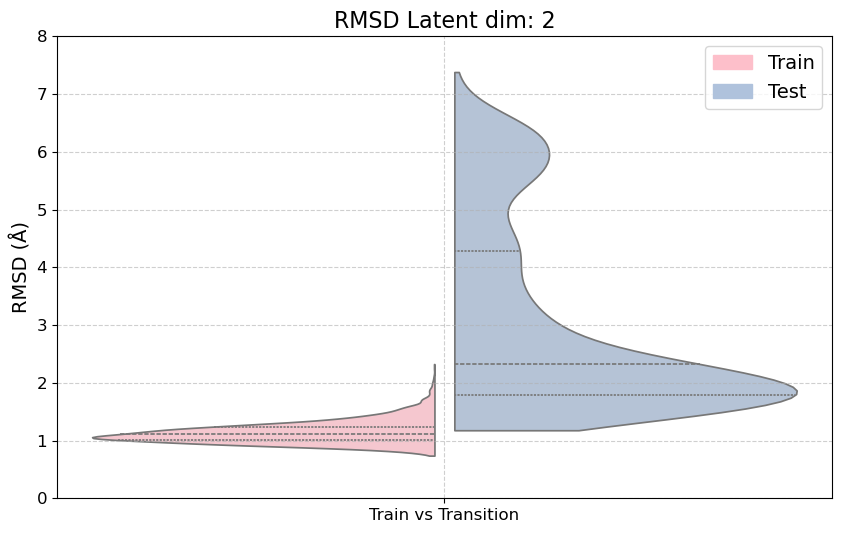

encoding train_both: 250it [00:00, 290.56it/s]
Decoding train_both: 250it [00:01, 170.00it/s]
encoding test_trans: 100it [00:00, 260.96it/s]
Decoding test_trans: 100it [00:00, 153.66it/s]


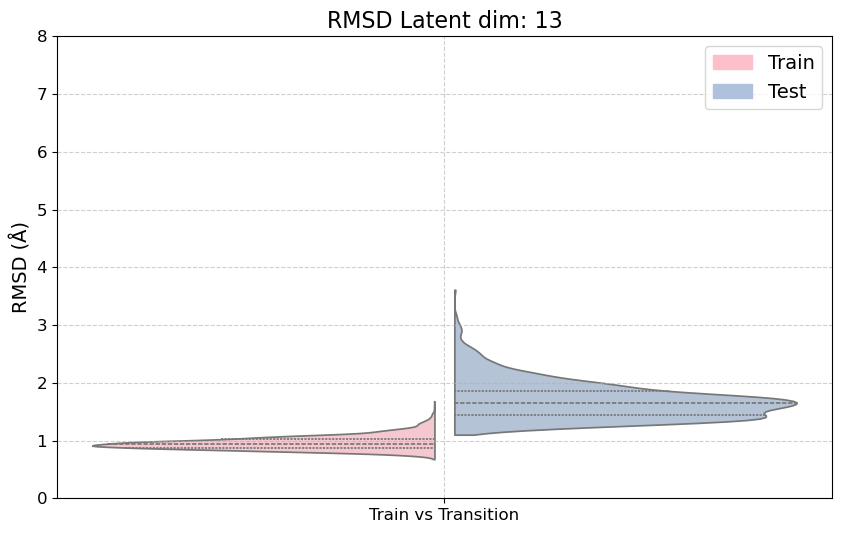

In [ ]:
for run, var in [[12, 2], [10, 13]]:
    rmsd_plot_data: PlotData = [
        ("train_both", "test_trans", "Train vs Transition", "train", "test"),
    ]

    plot_rmsd_hist(
        MAs[run][var],
        plot_data=rmsd_plot_data,
        dpi=150,
        var=var,
    )

#### Bondlength Hist plots

BOND LENGTH DISTRIBUTIONS - latent_dim=2


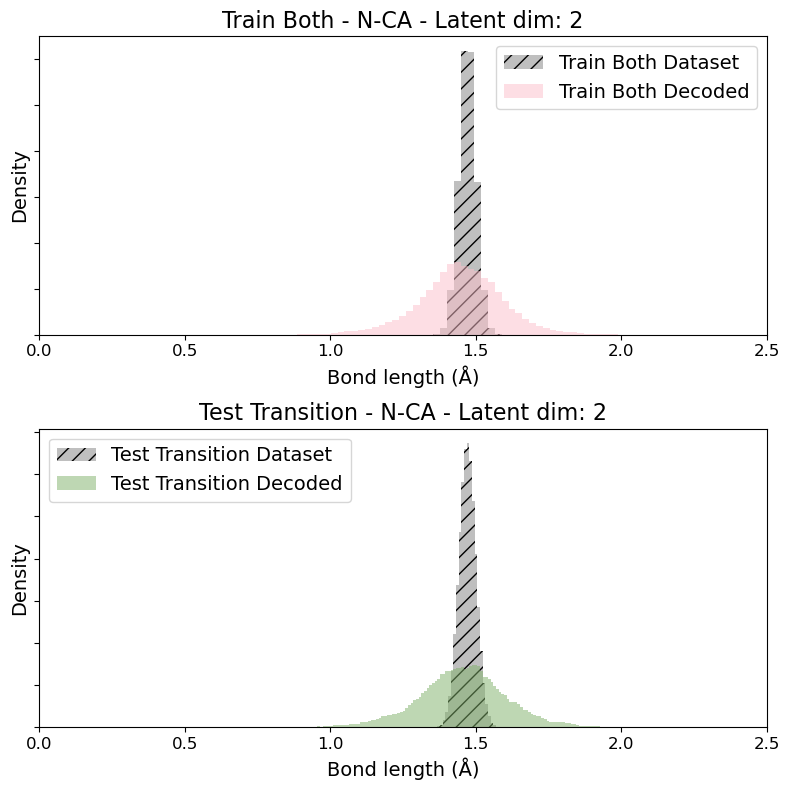

BOND LENGTH DISTRIBUTIONS - latent_dim=13


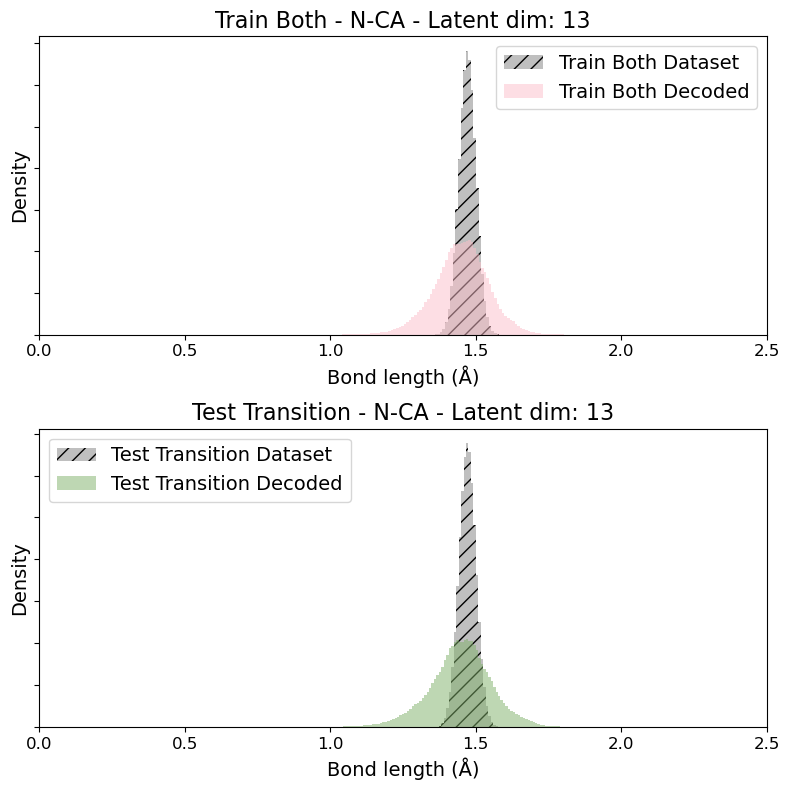

In [ ]:
for run, var in [[12, 2], [10, 13]]:
    print("=" * 60)
    print(f"BOND LENGTH DISTRIBUTIONS - latent_dim={var}")
    print("=" * 60)

    plot_bondlength_hist(
        MAs[run][var],
        plot_data=plot_data,
        bins=300,
        dpi=150,
        bond_types=["N-CA"],
        latent_dim=var,
    )

#### Inversion Hist Plot

INVERSION ERRORS - latent_dim=2, run=12


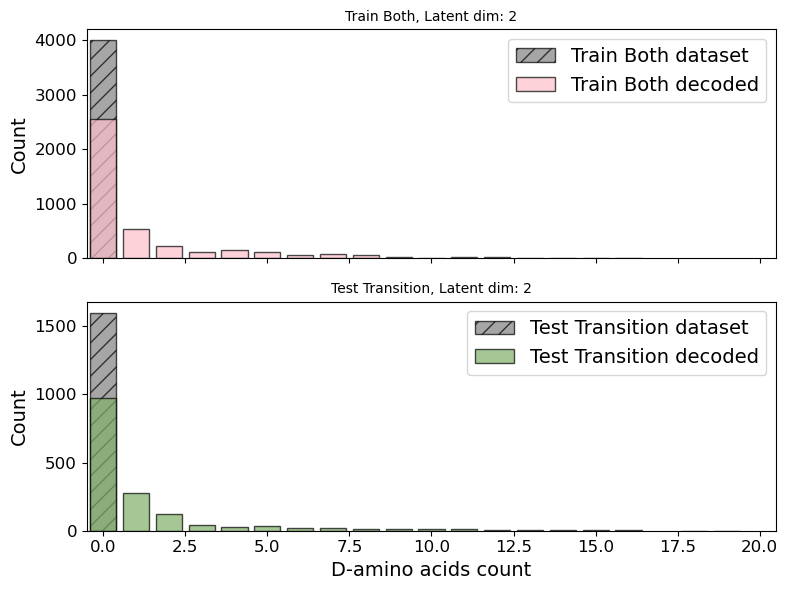

INVERSION ERRORS - latent_dim=13, run=10


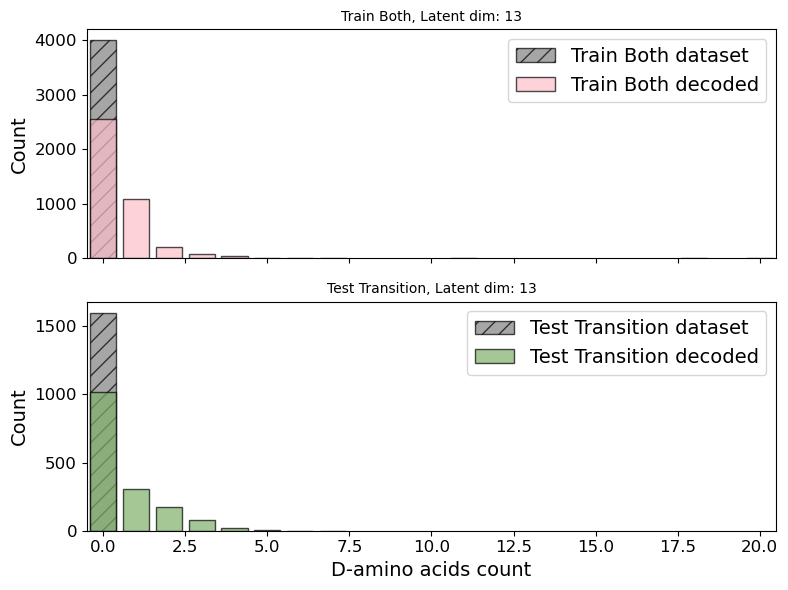

In [13]:
for run, var in [[12, 2], [10, 13]]:
    print("=" * 60)
    print(f"INVERSION ERRORS - latent_dim={var}, run={run}")
    print("=" * 60)

    plot_inversion_hist(
        MAs[run][var], plot_data=plot_data, latent_dim=var, show_plot=True
    )

#### Wiszniowski plot

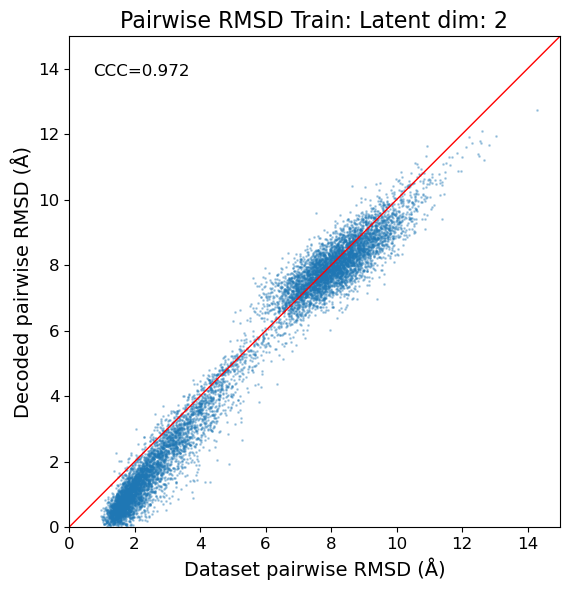

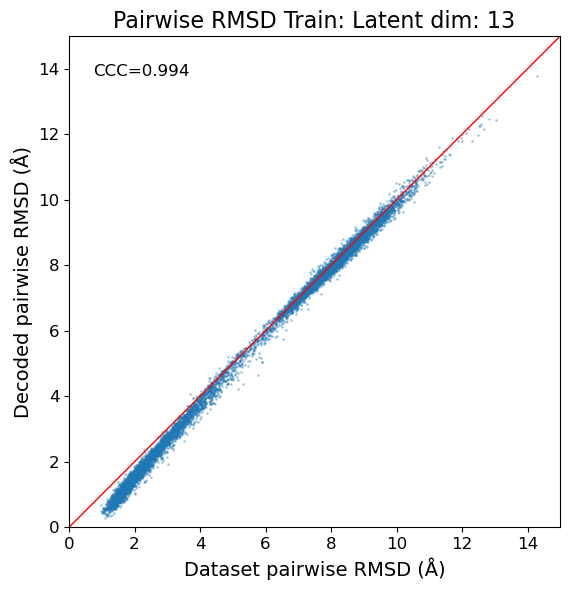

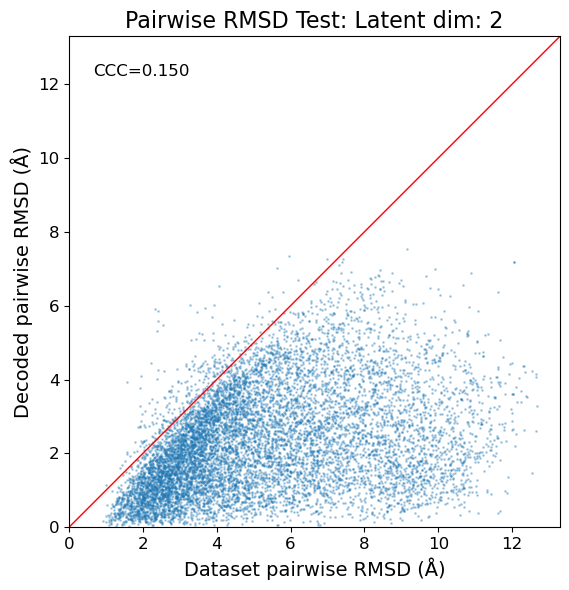

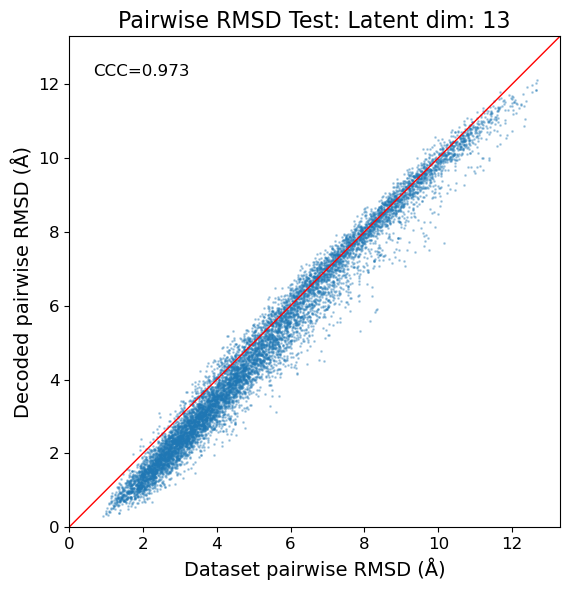

In [ ]:
for key in KEYS_BOTH:
    for run, var in [[12, 2], [10, 13]]:
        ccc, _, _ = plot_pairwise_rmsd(
            MAs[run][var],
            key=key,
            latent_dim=var,
            show_plot=True,
            title=f"Pairwise RMSD — Latent Dim {var}",
            max_pairs=10000,
        )

## 2D Hyperlatent representations


### Aggregated interpolation plots

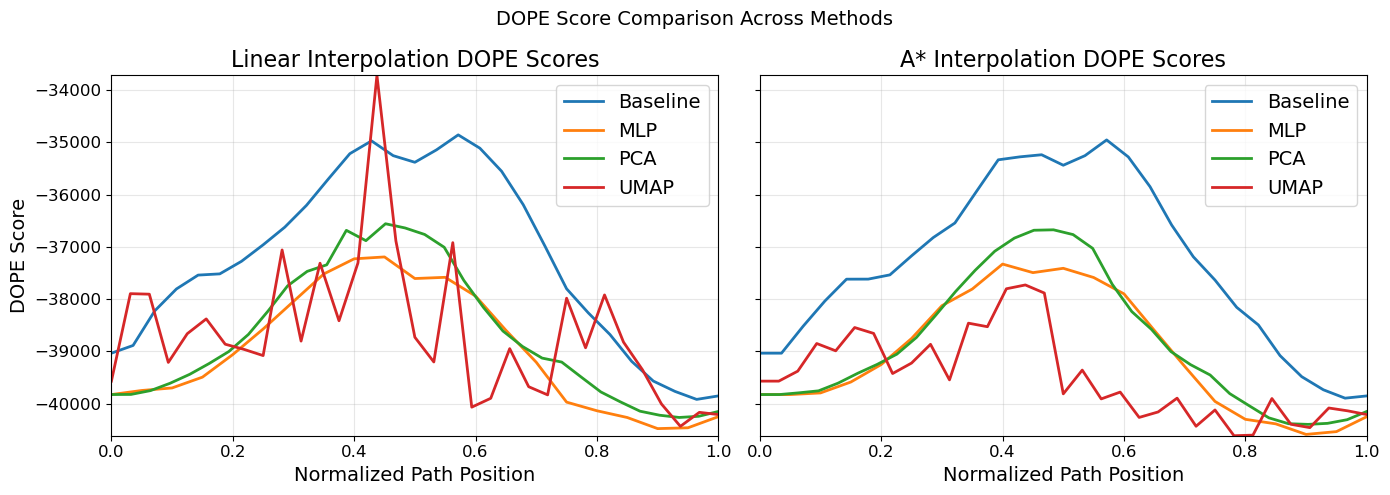

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Discover all saved DOPE score files in this directory.
score_dir = Path(".")
linear_files = sorted(score_dir.glob("*_linear_dope_scores.npy"))
astar_files = sorted(score_dir.glob("*_astar_dope_scores.npy"))

linear_scores: dict[str, np.ndarray] = {
    f.stem.replace("_linear_dope_scores", ""): np.load(f) for f in linear_files
}
astar_scores: dict[str, np.ndarray] = {
    f.stem.replace("_astar_dope_scores", ""): np.load(f) for f in astar_files
}

common_keys = sorted(set(linear_scores) & set(astar_scores))
if not common_keys:
    raise ValueError(
        "No matching linear/A* score files found. "
        "Expected files like '<name>_linear_dope_scores.npy' and '<name>_astar_dope_scores.npy'."
    )

# Use the same y-axis range for both plots.
all_values = [
    arr
    for k in common_keys
    for arr in (linear_scores[k], astar_scores[k])
    if len(arr) > 0
]
y_min = min(float(np.min(arr)) for arr in all_values)
y_max = max(float(np.max(arr)) for arr in all_values)

fig, (ax_linear, ax_astar) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for key in common_keys:
    lvals = linear_scores[key]
    avals = astar_scores[key]

    if len(lvals) > 1:
        x_linear = np.linspace(0.0, 1.0, len(lvals))
    elif len(lvals) == 1:
        x_linear = np.array([0.0])
    else:
        continue

    if len(avals) > 1:
        x_astar = np.linspace(0.0, 1.0, len(avals))
    elif len(avals) == 1:
        x_astar = np.array([0.0])
    else:
        continue

    ax_linear.plot(x_linear, lvals, linewidth=2, label=key)
    ax_astar.plot(x_astar, avals, linewidth=2, label=key)

ax_linear.set_title("Linear Interpolation DOPE Scores")
ax_linear.set_xlabel("Normalized Path Position")
ax_linear.set_ylabel("DOPE Score")
ax_linear.set_xlim(0.0, 1.0)
ax_linear.set_ylim(y_min, y_max)
ax_linear.grid(alpha=0.3)
ax_linear.legend()

ax_astar.set_title("A* Interpolation DOPE Scores")
ax_astar.set_xlabel("Normalized Path Position")
ax_astar.set_xlim(0.0, 1.0)
ax_astar.set_ylim(y_min, y_max)
ax_astar.grid(alpha=0.3)
ax_astar.legend()

fig.suptitle("DOPE Score Comparison Across Methods", fontsize=14)
fig.tight_layout()
plt.show()

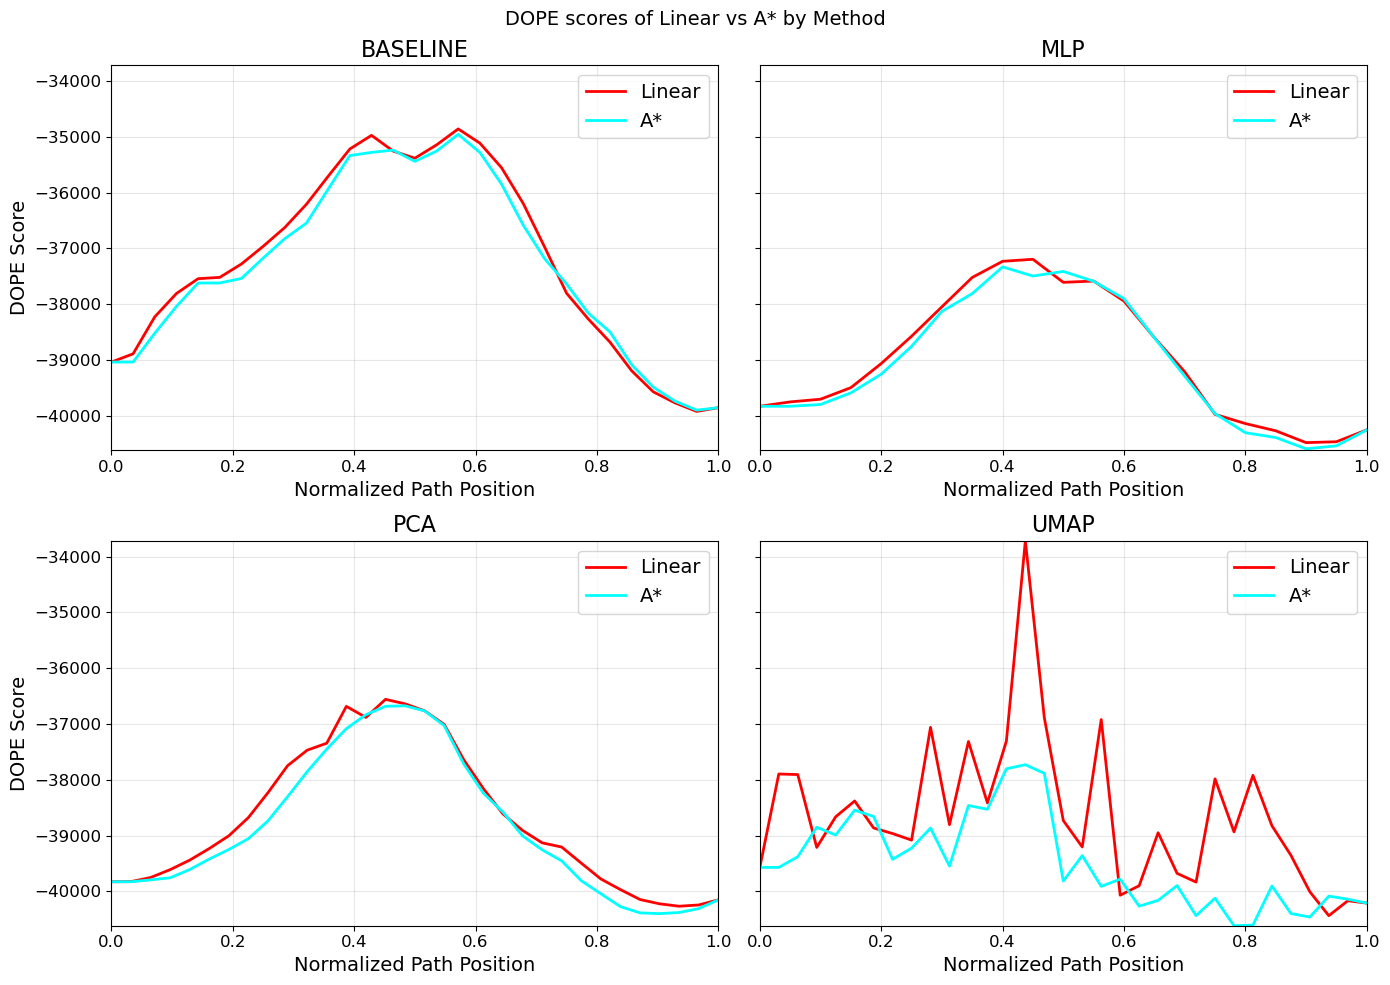

In [ ]:
# 2x2 comparison figure: linear vs A* within each method, with shared y-axis scale
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

score_dir = Path("../statistics/interp_scores")

linear_files = sorted(score_dir.glob("*_linear_dope_scores.npy"))
astar_files = sorted(score_dir.glob("*_astar_dope_scores.npy"))

linear_scores: dict[str, np.ndarray] = {
    f.stem.replace("_linear_dope_scores", ""): np.load(f) for f in linear_files
}
astar_scores: dict[str, np.ndarray] = {
    f.stem.replace("_astar_dope_scores", ""): np.load(f) for f in astar_files
}

keys = sorted(set(linear_scores) & set(astar_scores))


# Global y-limits across every selected subplot and both interpolation modes.
all_values = []
for key in keys:
    all_values.append(linear_scores[key])
    all_values.append(astar_scores[key])

y_min = min(float(np.min(arr)) for arr in all_values)
y_max = max(float(np.max(arr)) for arr in all_values)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.ravel()

for i, key in enumerate(keys):
    ax = axes[i]
    lvals = linear_scores[key]
    avals = astar_scores[key]

    if len(lvals) > 1:
        x_linear = np.linspace(0.0, 1.0, len(lvals))
    elif len(lvals) == 1:
        x_linear = np.array([0.0])
    else:
        x_linear = np.array([])

    if len(avals) > 1:
        x_astar = np.linspace(0.0, 1.0, len(avals))
    elif len(avals) == 1:
        x_astar = np.array([0.0])
    else:
        x_astar = np.array([])

    if len(x_linear) > 0:
        ax.plot(x_linear, lvals, linewidth=2, label="Linear", color="red")
    if len(x_astar) > 0:
        ax.plot(x_astar, avals, linewidth=2, label="A*", color="cyan")

    ax.set_title(key.upper())
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel("Normalized Path Position")
    ax.grid(alpha=0.3)
    ax.legend()

# Hide any unused axes (in case fewer than 4 are plotted).
for j in range(len(keys), 4):
    axes[j].axis("off")

axes[0].set_ylabel("DOPE Score")
axes[2].set_ylabel("DOPE Score")
fig.suptitle("DOPE scores of Linear vs A* by Method", fontsize=14)
fig.tight_layout()
plt.show()

### Setup

In [2]:
run = 1
var = 2

ma = MAs[run][var]

encoded_test: np.ndarray = MAs[run][var].get_encoded("test_trans").numpy()
encoded_open: np.ndarray = MAs[run][var].get_encoded("train_open").numpy()
encoded_closed: np.ndarray = MAs[run][var].get_encoded("train_closed").numpy()
encoded_all = np.vstack([encoded_test, encoded_open, encoded_closed])

centroid_open = encoded_open.mean(axis=0)
centroid_closed = encoded_closed.mean(axis=0)

encoded_datasets = [
    (encoded_test, "Test Transition", TEST_COLOR),
    (encoded_open, "Train Open", OPEN_COLOR),
    (encoded_closed, "Train Closed", CLOSED_COLOR),
]

plot_data: PlotData = [
    ("train_both", "Train Closed", BOTH_COLOR),
    ("test_trans", "Test Transition", TEST_COLOR),
]

encoding test_trans: 0it [00:00, ?it/s]

encoding test_trans: 100it [00:00, 109.00it/s]
encoding train_open: 125it [00:00, 142.67it/s]
encoding train_closed: 125it [00:00, 142.31it/s]


### 2D Dope

Decoding 60x60 = 3600 grid points...
Computing DOPE scores...


Calc Dope: 100%|██████████| 29/29 [00:01<00:00, 17.47it/s]


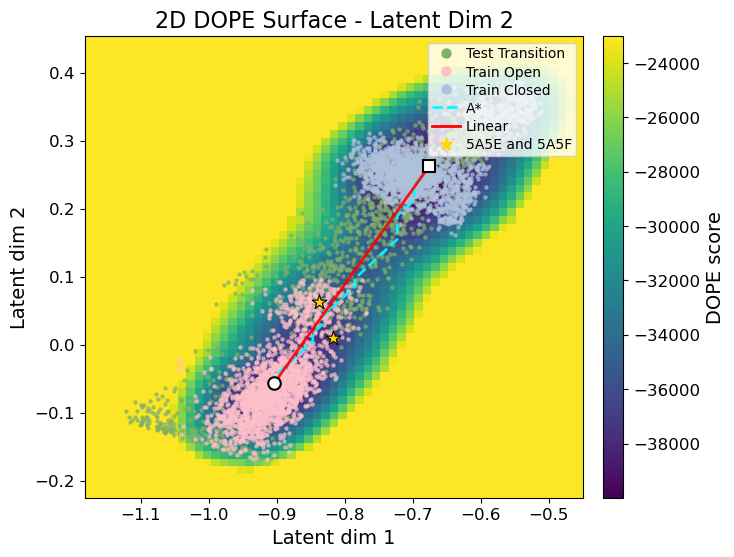

In [8]:
dope_surface, d1_vals, d2_vals, fig, ax, paths = plot_dope_mesh(
    ma=ma,
    encoded_datasets=encoded_datasets,
    mapping=lambda x: x,
    inverse_mapping=lambda x: x,
    n_samples=N_SAMPLES,
    refine=REFINE,
    truncate_at=TRUNCATE_AT,
    title=f"2D DOPE Surface - Latent Dim {var}",
    xlabel="Latent dim 1",
    ylabel="Latent dim 2",
    start_encoded=centroid_open,
    end_encoded=centroid_closed,
    # fname=f"../figures/target/pca/dope_r{run}_v{var}",
    show=True,
)


np.save("d2_linear_dope_scores.npy", paths["linear"]["dope"])
np.save("d2_astar_dope_scores.npy", paths["astar"]["dope"])

### PCA

encoding train_both: 250it [00:01, 157.84it/s]


Decoding 60x60 = 3600 grid points...
Computing DOPE scores...


Calc Dope: 100%|██████████| 32/32 [00:01<00:00, 18.15it/s]
encoding 5A5E: 1it [00:00, 205.46it/s]
encoding 5A5F: 1it [00:00, 485.85it/s]


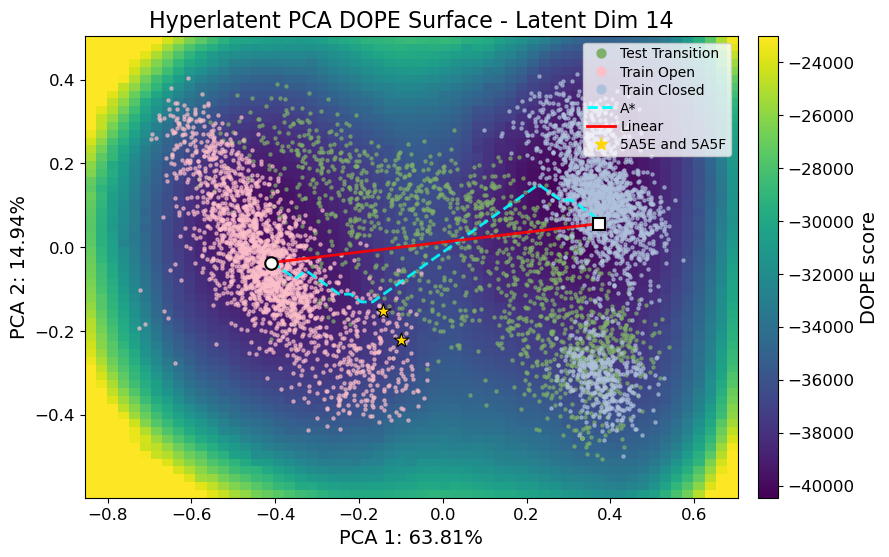

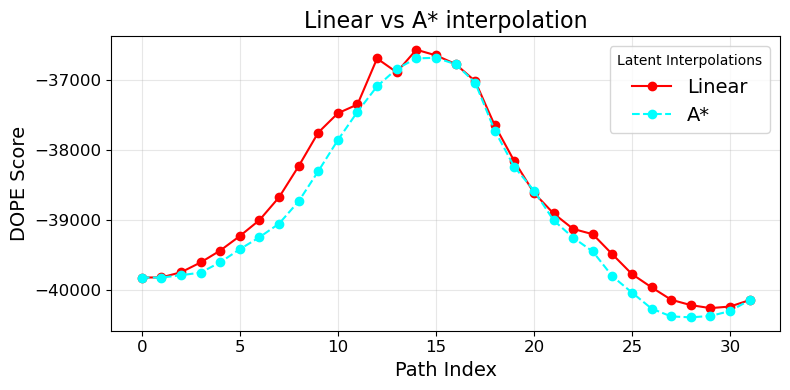

In [4]:
pca_mas, mappings, inverse_mappings, pca_variances = make_hyperlatent_pca_mas(
    MAs, [run], [var], KEYS_ALL
)

pca_ma = pca_mas[run][var]
mapping = mappings[run][var]
inverse_mapping = inverse_mappings[run][var]
pca_variance = pca_variances[run][var]


# get_all_base_plots(
#     ma=pca_ma,
#     keys=KEYS_ALL,
#     plot_data=plot_data,
#     latent_dim=var,
#     run=run,
#     save_dir="../figures/target/pca/",
#     show=False,
# )

# get_all_stats(
#     mas=pca_mas,
#     varis=[var],
#     runs=[run],
#     keys=KEYS_ALL,
#     save_dir=f"../statistics/pca.csv",
#     random_state=RANDOM_STATE,
# )

dope_surface, d1_vals, d2_vals, fig, ax, paths = plot_dope_mesh(
    ma=pca_ma,
    encoded_datasets=encoded_datasets,
    mapping=mapping,
    inverse_mapping=inverse_mapping,
    n_samples=N_SAMPLES,
    refine=REFINE,
    truncate_at=TRUNCATE_AT,
    title=f"Hyperlatent PCA DOPE Surface - Latent Dim {var}",
    xlabel=f"PCA 1: {round(pca_variance[0], 2)}%",
    ylabel=f"PCA 2: {round(pca_variance[1], 2)}%",
    start_encoded=centroid_open,
    end_encoded=centroid_closed,
    fname=f"../figures/target/pca/dope_r{run}_v{var}",
)

gc.collect()
torch.cuda.empty_cache()


np.save("pca_linear_dope_scores.npy", paths["linear"]["dope"])
np.save("pca_astar_dope_scores.npy", paths["astar"]["dope"])

plot_dope_interp_scores(
    linear_scores=paths["linear"]["dope"],
    astar_scores=paths["astar"]["dope"],
    title="Linear vs A* interpolation",
    fname=f"../figures/target/pca/interp_r{run}_v{var}",
)

### UMAP

encoding train_open: 125it [00:00, 285.12it/s]
encoding train_closed: 125it [00:00, 286.52it/s]
encoding train_both: 250it [00:00, 263.33it/s]
encoding test_trans: 100it [00:00, 277.44it/s]


Decoding 60x60 = 3600 grid points...
Computing DOPE scores...


Calc Dope: 100%|██████████| 33/33 [00:01<00:00, 17.20it/s]
encoding 5A5E: 1it [00:00, 501.65it/s]
encoding 5A5F: 1it [00:00, 480.34it/s]


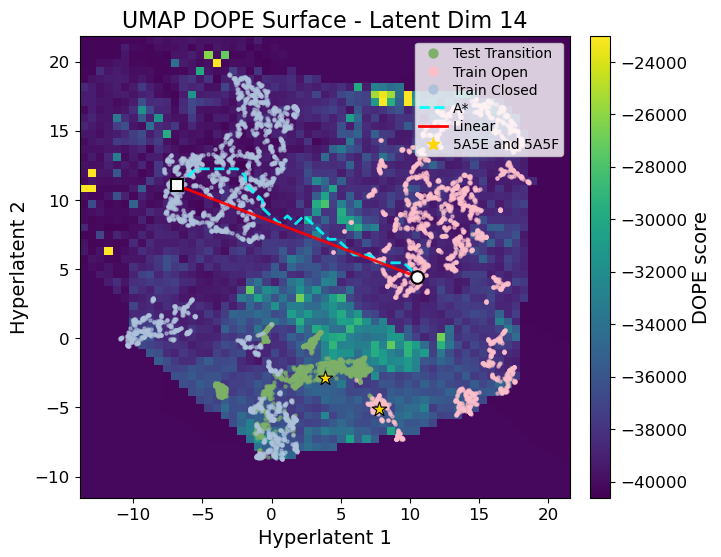

In [5]:
umap_mas, mappings, inverse_mappings = make_hyperlatent_umap_mas(
    MAs, [run], [var], KEYS_ALL, n_neighbors=12, min_dist=0.1
)

umap_ma = umap_mas[run][var]
mapping = mappings[run][var]
inverse_mapping = inverse_mappings[run][var]

# get_all_base_plots(
#     ma=umap_ma,
#     keys=KEYS_ALL,
#     plot_data=plot_data,
#     latent_dim=var,
#     run=run,
#     save_dir="../figures/target/umap/",
#     show=False,
# )

# get_all_stats(
#     mas=umap_mas,
#     varis=[var],
#     runs=[run],
#     keys=KEYS_ALL,
#     save_dir="../statistics/umap.csv",
#     random_state=RANDOM_STATE,
# )


dope_surface, d1_vals, d2_vals, fig, ax, paths = plot_dope_mesh(
    ma=umap_ma,
    encoded_datasets=encoded_datasets,
    mapping=mapping,
    inverse_mapping=inverse_mapping,
    n_samples=N_SAMPLES,
    refine=REFINE,
    truncate_at=TRUNCATE_AT,
    title=f"UMAP DOPE Surface - Latent Dim {var}",
    xlabel="Hyperlatent 1",
    ylabel="Hyperlatent 2",
    plot_astar=True,
    plot_linear=True,
    plot_crystals=True,
    start_encoded=centroid_open,
    end_encoded=centroid_closed,
    fname=f"../figures/target/umap/dope_r{run}_v{var}",
)

linear = paths["linear"]
a_star = paths["astar"]

np.save("umap_linear_dope_scores.npy", paths["linear"]["dope"])
np.save("umap_astar_dope_scores.npy", paths["astar"]["dope"])


# plot_dope_interp_scores(
#     linear_scores=linear["dope"],
#     astar_scores=a_star["dope"],
#     title="Linear vs A* interpolation",
#     fname=f"../figures/target/umap/interp_r{run}_v{var}",
# )

gc.collect()
torch.cuda.empty_cache()

### Multilayer Perceptron

#### Testing objective functions

In [ ]:
weights = [
    # [1, 0, 0, 0], local rmsd
    # [1, 0, 0, 0],
    # [1, 0, 0, 0],
    # [0, 1, 0, 0], local pairwise distance
    # [0, 1, 0, 0],
    # [0, 1, 0, 0],
    # [0, 0, 1, 0], global rmsd
    # [0, 0, 1, 0],
    # [0, 0, 1, 0],
    # [0, 0, 0, 1], global pairwise distance
    # [0, 0, 0, 1],
    # [0, 0, 0, 1],
]

mlp_mas = {}
mappings = {}
inverse_mappings = {}

for i, weight in enumerate(weights):
    mlp_mas[i], mappings[i], inverse_mappings[i] = make_hyperlatent_mlp_mas(
        MAs, [run], [var], KEYS_ALL, weight, epochs=100
    )

    ma = mlp_mas[i][run][var]
    mapping = mappings[i][run][var]
    inverse_mapping = inverse_mappings[i][run][var]

    get_all_stats(
        mas=mlp_mas[i],
        varis=[var],
        runs=[run],
        keys=KEYS_ALL,
        save_dir=f"../statistics/mlp_stats_weight_after_invincibiles_{i}.csv",
        random_state=RANDOM_STATE + i,
    )

    # all_base_plots(
    #     ma=ma,
    #     keys=KEYS_BOTH,
    #     plot_data=plot_data,
    #     latent_dim=var,
    #     run=run,
    #     save_dir=f"../figures/test/mlp/climbing_gym2{i}/",
    # )

    # plot_dope_mesh(
    #     ma=ma,
    #     encoded_datasets=encoded_datasets,
    #     mapping=mapping,
    #     inverse_mapping=inverse_mapping,
    #     truncate_at=TRUNCATE_AT,
    #     n_samples=N_SAMPLES,
    #     refine=REFINE,
    # )

    gc.collect()
    torch.cuda.empty_cache()

encoding train_both: 250it [00:01, 185.62it/s]
Decoding train_open: 125it [00:01, 117.61it/s]
Decoding train_closed: 125it [00:00, 154.54it/s]
Decoding train_both: 250it [00:01, 140.50it/s]
Decoding test_trans: 100it [00:00, 139.62it/s]
encoding train_open: 125it [00:00, 202.49it/s]
encoding train_closed: 125it [00:00, 195.25it/s]
encoding train_both: 250it [00:01, 177.59it/s]
encoding test_trans: 100it [00:00, 169.24it/s]
Decoding train_open: 125it [00:00, 149.13it/s]
Decoding train_closed: 125it [00:00, 138.22it/s]
Decoding train_both: 250it [00:01, 134.78it/s]
Decoding test_trans: 100it [00:00, 139.33it/s]
encoding train_open: 125it [00:00, 199.87it/s]
encoding train_closed: 125it [00:00, 206.07it/s]
encoding train_both: 250it [00:01, 189.81it/s]
encoding test_trans: 100it [00:00, 191.65it/s]
Decoding train_open: 125it [00:00, 153.06it/s]
Decoding train_closed: 125it [00:00, 152.15it/s]
Decoding train_both: 250it [00:01, 143.17it/s]
Decoding test_trans: 100it [00:00, 133.40it/s]


#### Hyper parameter tuning

In [13]:
weight = [0, 0, 1, 0]  # global RMSD only
loss_func = composite_loss(ma, weight)


def objective(trial):
    lr = trial.suggest_loguniform("lr", 1e-5, 1e-3)
    hidden_dim = trial.suggest_categorical("hidden_dim", [64, 128, 256])
    num_layers = trial.suggest_int("num_layers", 2, 6)
    dropout = trial.suggest_uniform("dropout", 0.0, 0.1)

    model = LatentAutoencoder(
        input_dim=var,
        latent_dim=2,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout,
    )

    train_config = TrainConfig(
        ma=ma,
        model=model,
        keys=["train_both"],
        epochs=100,
        loss_func=loss_func,
        verbose=False,
        lr=lr,
        batch_size=64,
    )

    # Train and evaluate
    mlp_mas, mappings, inverse_mappings, val_loss = make_hyperlatent_mlp_mas(
        MAs, [run], [var], KEYS_ALL, train_config
    )
    # Return validation loss or other metric
    loss = val_loss[run][var]  # extract from logs or output

    gc.collect()
    torch.cuda.empty_cache()

    return loss


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

[I 2026-03-31 18:22:11,134] A new study created in memory with name: no-name-5b2900da-4673-4223-8909-b06755a4979a
encoding train_open: 125it [00:00, 209.87it/s]
encoding train_closed: 125it [00:00, 189.74it/s]
encoding train_both: 250it [00:01, 240.24it/s]
[I 2026-03-31 18:37:49,819] Trial 0 finished with value: 0.2638368734291622 and parameters: {'lr': 2.6846807726873752e-05, 'hidden_dim': 128, 'num_layers': 4, 'dropout': 0.08366814302621063}. Best is trial 0 with value: 0.2638368734291622.
encoding train_open: 125it [00:00, 268.75it/s]
encoding train_closed: 125it [00:00, 273.81it/s]
encoding train_both: 250it [00:00, 274.46it/s]
encoding test_trans: 100it [00:00, 228.81it/s]
[I 2026-03-31 18:53:55,451] Trial 1 finished with value: 0.03486240761620658 and parameters: {'lr': 8.780529251476553e-05, 'hidden_dim': 64, 'num_layers': 4, 'dropout': 0.05740548793122399}. Best is trial 1 with value: 0.03486240761620658.
encoding train_open: 125it [00:00, 229.63it/s]
encoding train_closed: 125

#### Saving stats and plots

Epoch 10/100 — Best val loss: 0.032959
Epoch 20/100 — Best val loss: 0.031161
Epoch 30/100 — Best val loss: 0.030377
Epoch 40/100 — Best val loss: 0.030377
Epoch 50/100 — Best val loss: 0.029929
Epoch 60/100 — Best val loss: 0.029929
Epoch 70/100 — Best val loss: 0.029929
Epoch 80/100 — Best val loss: 0.029453
Epoch 90/100 — Best val loss: 0.029453
Epoch 100/100 — Best val loss: 0.029453


Decoding train_open: 125it [00:00, 138.24it/s]
Decoding train_closed: 125it [00:00, 140.63it/s]
Decoding train_both: 250it [00:01, 128.44it/s]
Decoding test_trans: 100it [00:00, 119.36it/s]


Decoding 60x60 = 3600 grid points...
Computing DOPE scores...


Calc Dope: 100%|██████████| 21/21 [00:01<00:00, 17.00it/s]
encoding 5A5E: 1it [00:00, 127.15it/s]
encoding 5A5F: 1it [00:00, 444.92it/s]
encoding train_open: 125it [00:00, 232.98it/s]
encoding train_closed: 125it [00:00, 264.64it/s]
encoding train_both: 250it [00:00, 261.00it/s]
encoding test_trans: 100it [00:00, 266.98it/s]


Epoch 10/100 — Best val loss: 0.029647
Epoch 20/100 — Best val loss: 0.029295
Epoch 30/100 — Best val loss: 0.029295
Epoch 40/100 — Best val loss: 0.029295
Epoch 50/100 — Best val loss: 0.029295
Epoch 60/100 — Best val loss: 0.029295
Epoch 70/100 — Best val loss: 0.029295
Epoch 80/100 — Best val loss: 0.029295
Epoch 90/100 — Best val loss: 0.029295
Epoch 100/100 — Best val loss: 0.029295


...

Calc Dope: 100%|██████████| 19/19 [00:01<00:00, 17.62it/s]
encoding 5A5E: 1it [00:00, 423.80it/s]
encoding 5A5F: 1it [00:00, 597.22it/s]
encoding train_open: 125it [00:00, 267.20it/s]
encoding train_closed: 125it [00:00, 270.80it/s]
encoding train_both: 250it [00:01, 213.84it/s]
encoding test_trans: 100it [00:00, 271.41it/s]


Epoch 10/100 — Best val loss: 0.029755
Epoch 20/100 — Best val loss: 0.029570
Epoch 30/100 — Best val loss: 0.029570
Epoch 40/100 — Best val loss: 0.029570
Epoch 50/100 — Best val loss: 0.029570
Epoch 60/100 — Best val loss: 0.029570
Epoch 70/100 — Best val loss: 0.029339
Epoch 80/100 — Best val loss: 0.029339
Epoch 90/100 — Best val loss: 0.029339
Epoch 100/100 — Best val loss: 0.029339


Exception ignored in atexit callback: Exception ignored in atexit callback: <function _cleanup_connections at 0x7feecb569c60>
<function _cleanup_connections at 0x7fb475eb5c60>Traceback (most recent call last):

  File "/home/brian-daniel/miniconda3/envs/molearn/lib/python3.11/site-packages/filelock/_read_write.py", line 26, in _cleanup_connections
Traceback (most recent call last):
  File "/home/brian-daniel/miniconda3/envs/molearn/lib/python3.11/site-packages/filelock/_read_write.py", line 26, in _cleanup_connections
    def _cleanup_connections() -> None:
    def _cleanup_connections() -> None:
    
    
  File "/home/brian-daniel/miniconda3/envs/molearn/lib/python3.11/site-packages/gsd/__init__.py", line 25, in <lambda>
  File "/home/brian-daniel/miniconda3/envs/molearn/lib/python3.11/site-packages/gsd/__init__.py", line 25, in <lambda>
    signal.signal(signal.SIGTERM, lambda n, f: sys.exit(1))
    signal.signal(signal.SIGTERM, lambda n, f: sys.exit(1))
                            

Decoding 60x60 = 3600 grid points...
Computing DOPE scores...


Calc Dope: 100%|██████████| 19/19 [00:01<00:00, 16.27it/s]
encoding 5A5E: 1it [00:00, 330.42it/s]
encoding 5A5F: 1it [00:00, 421.28it/s]


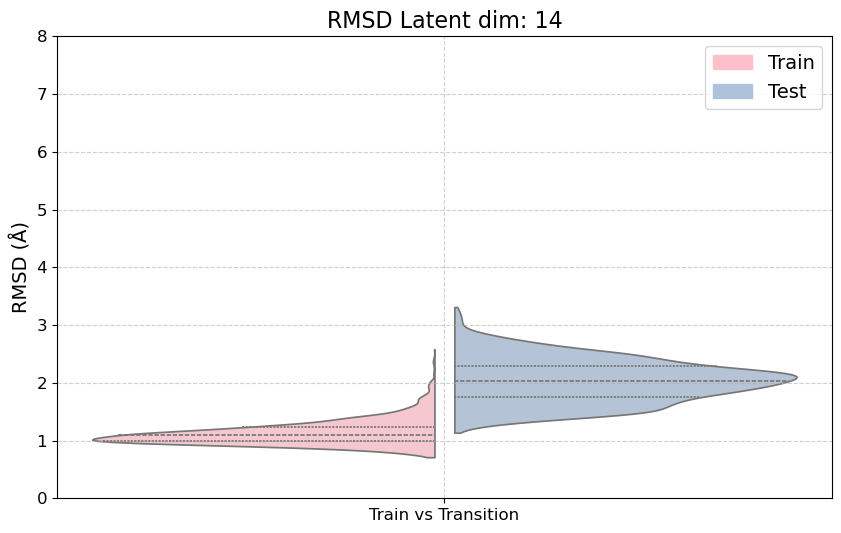

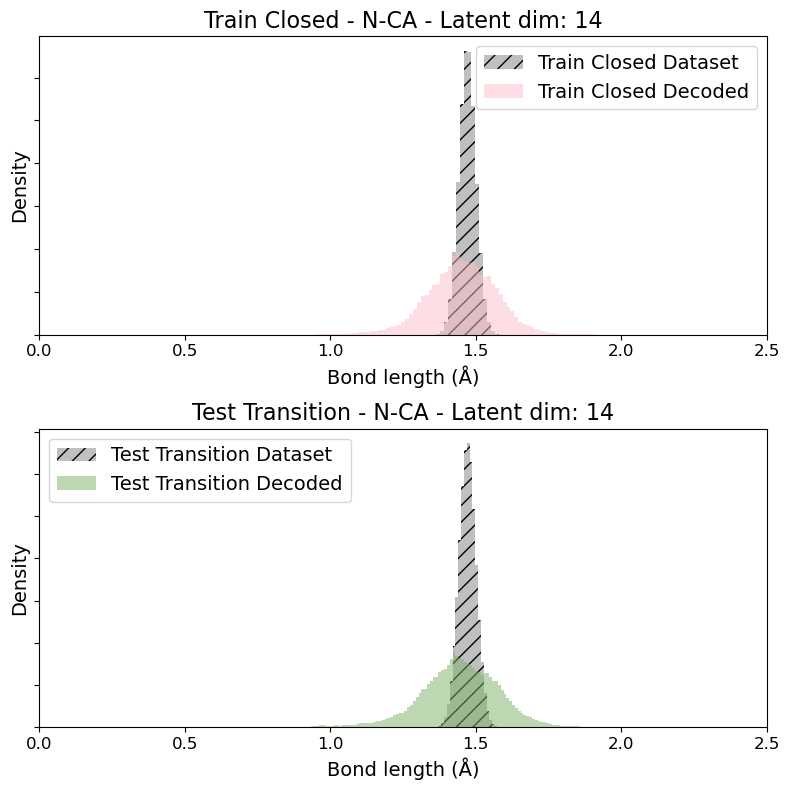

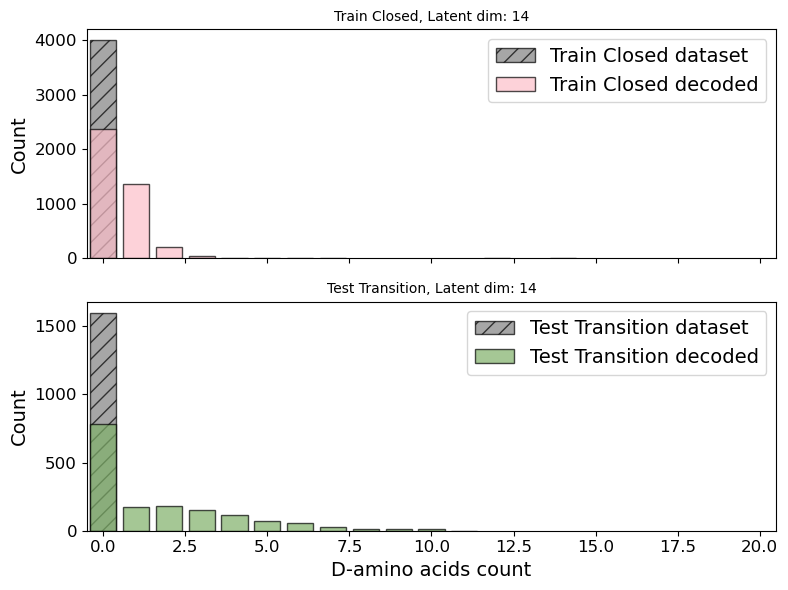

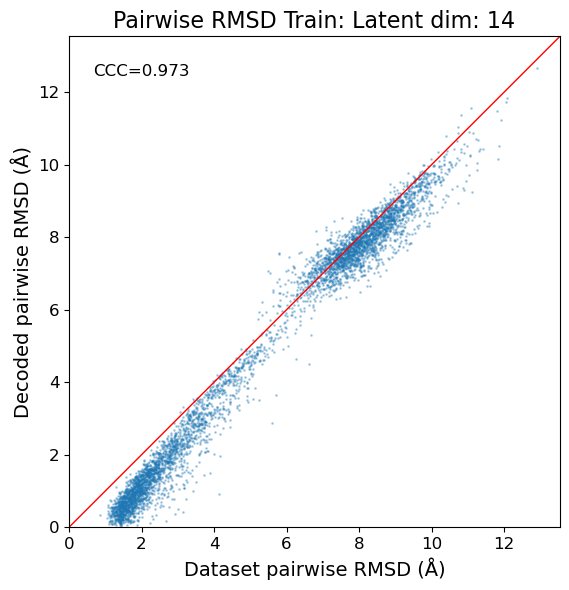

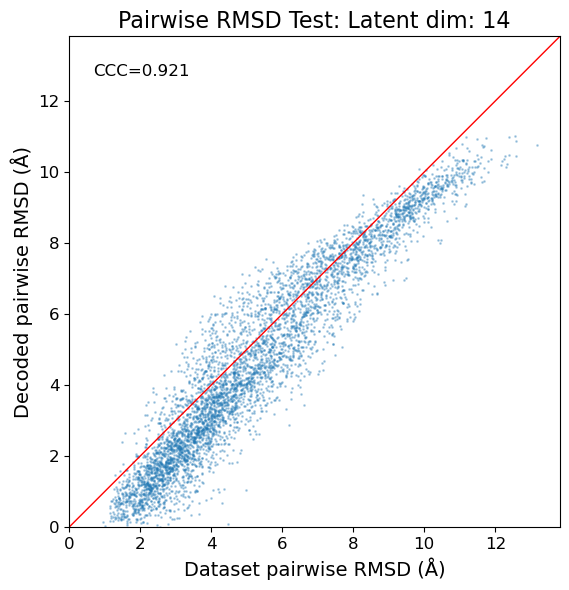

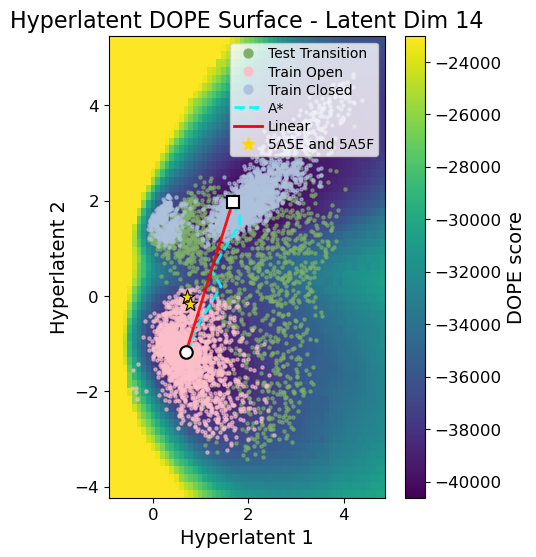

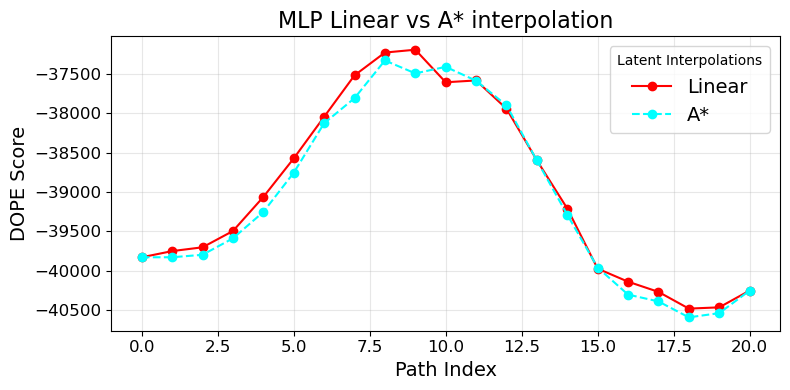

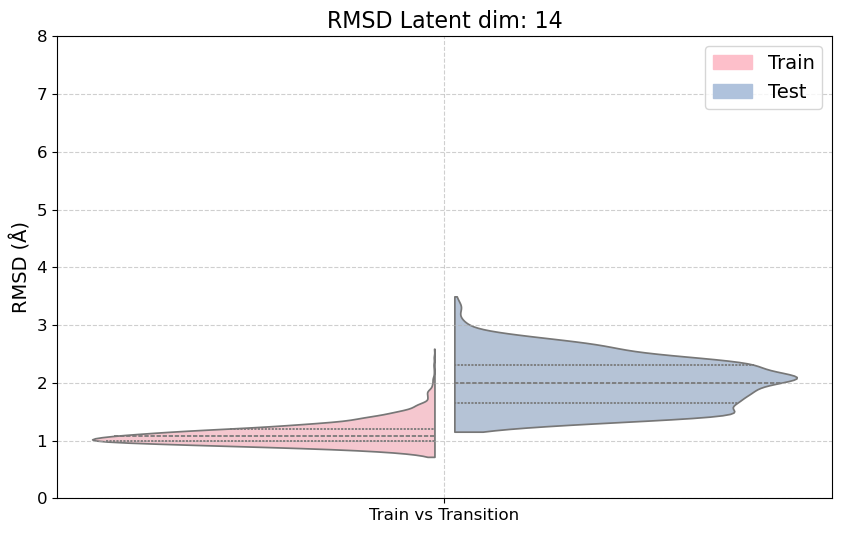

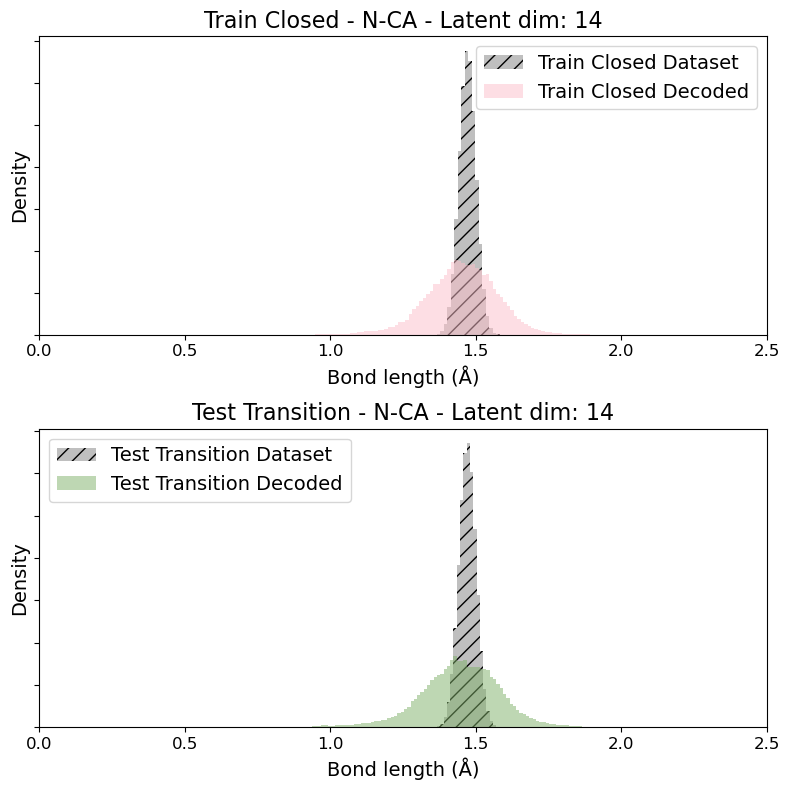

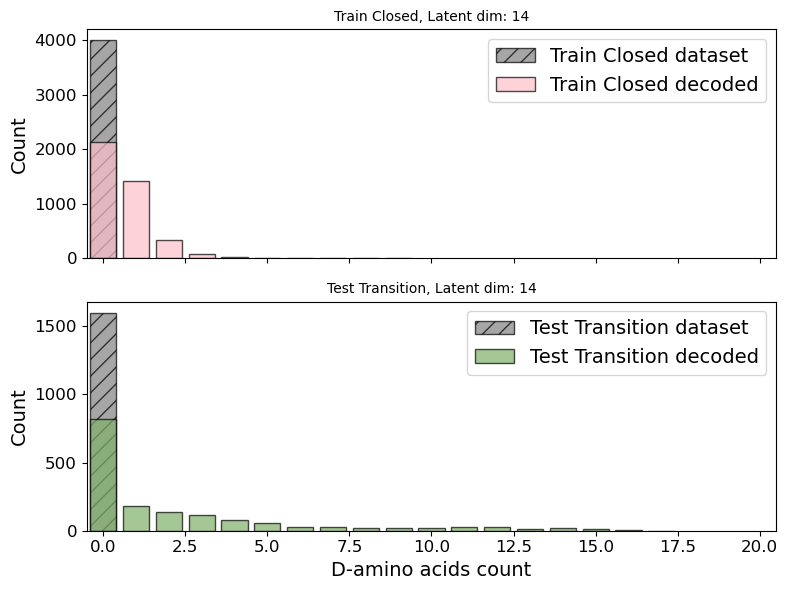

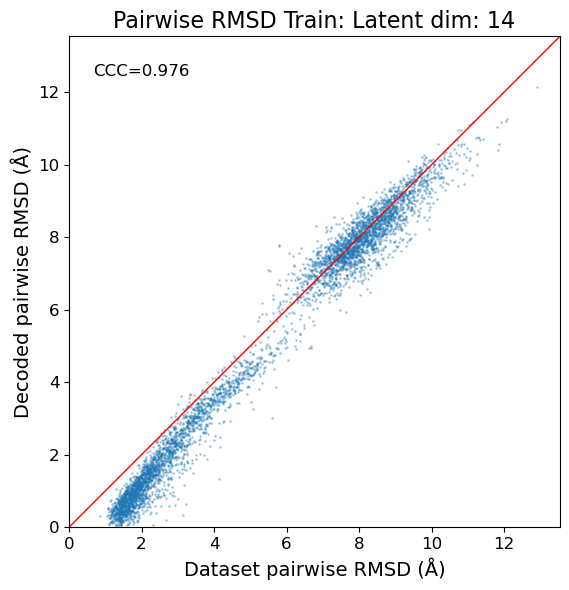

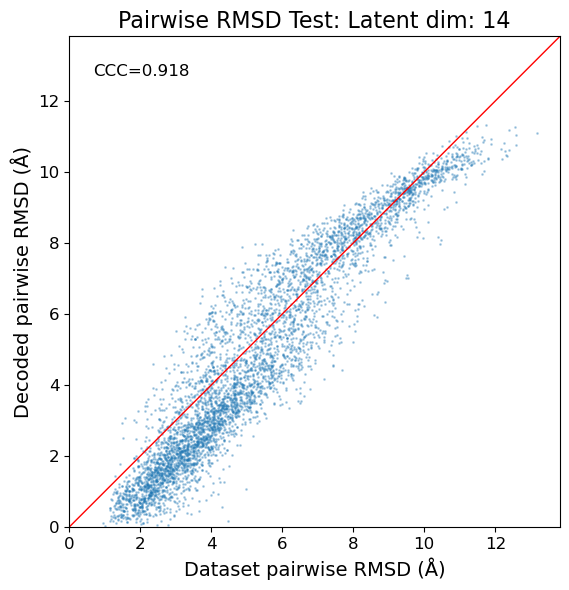

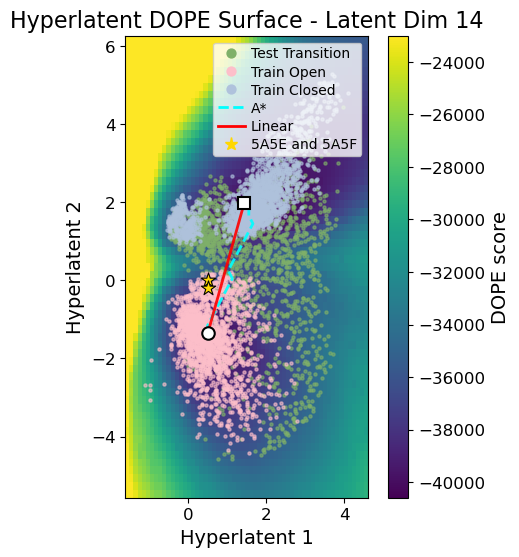

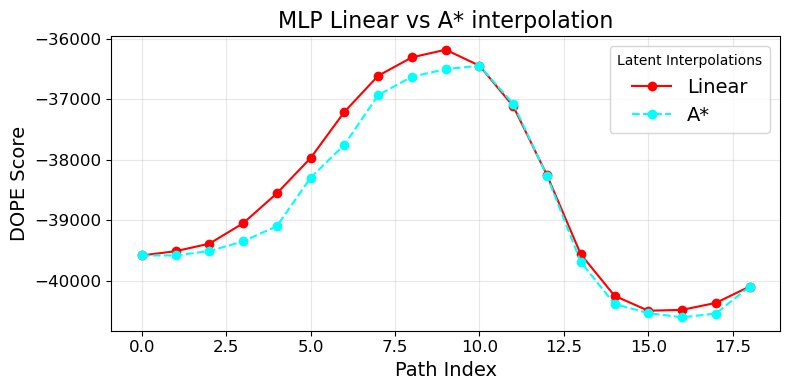

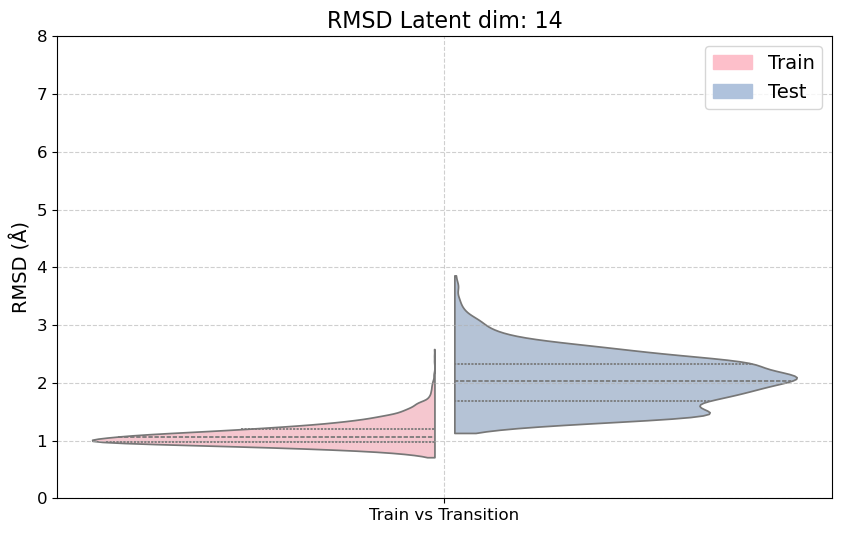

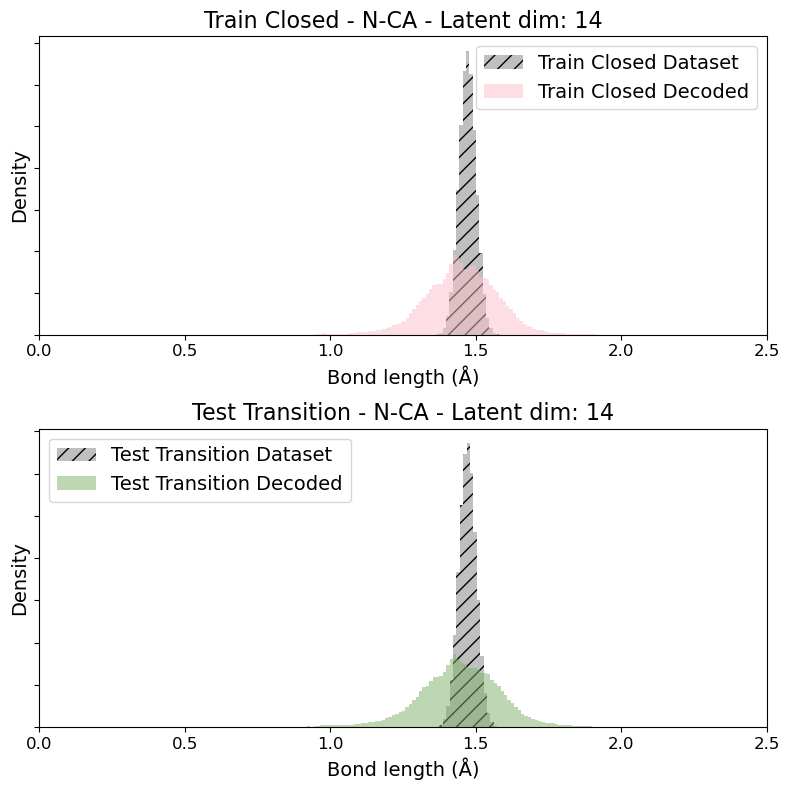

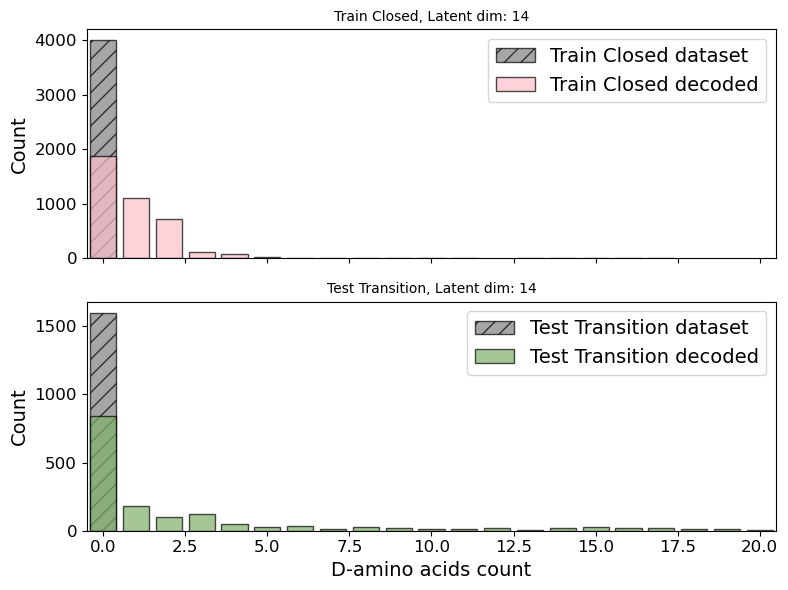

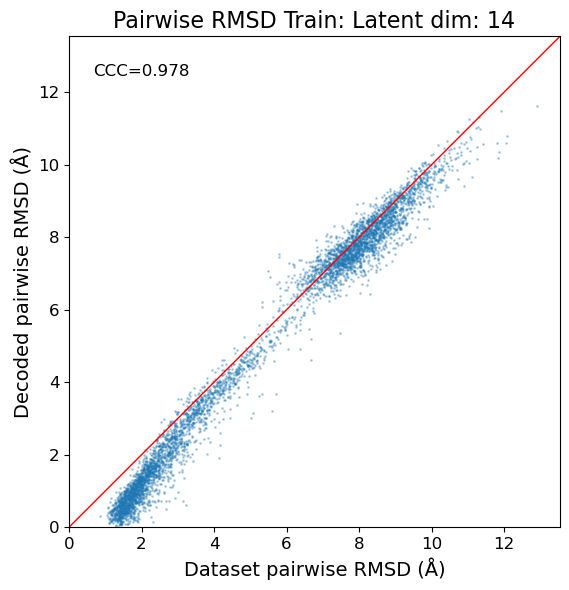

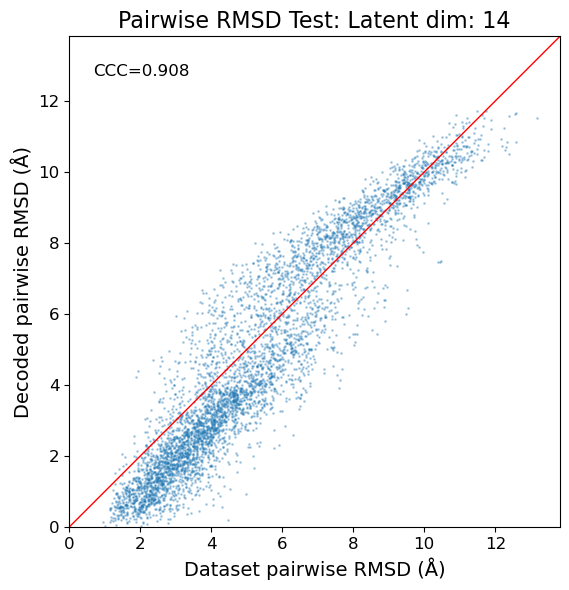

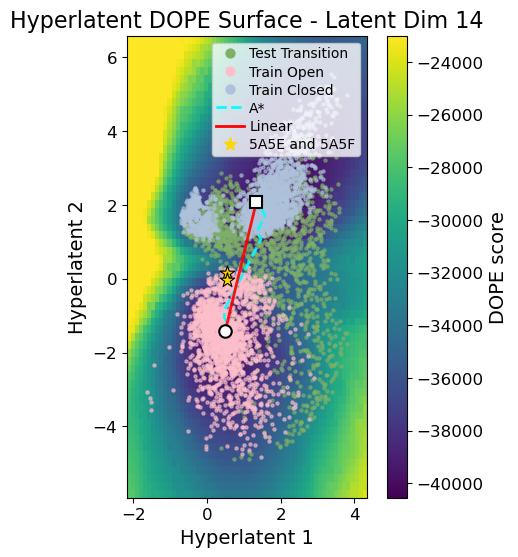

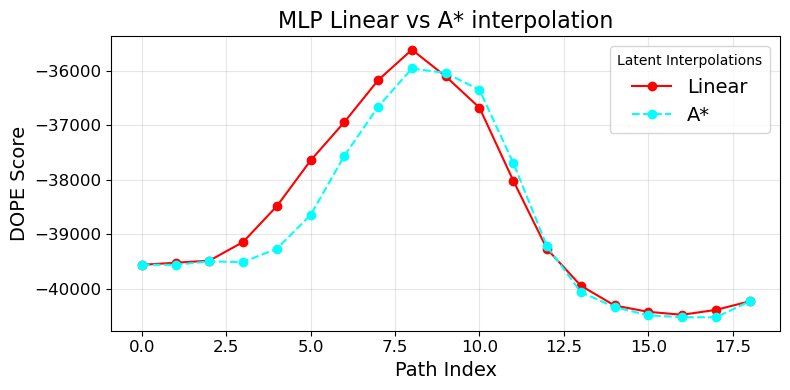

In [4]:
weight = [0, 0, 1, 0]
loss_func = composite_loss(ma, weight)
tuned_params = {
    "lr": 0.0007797117540880056,
    "hidden_dim": 256,
    "num_layers": 4,
    "dropout": 0.022230379008573713,
}

# {'lr': 0.00033228392498695, 'hidden_dim': 256, 'num_layers': 6, 'dropout': 0.035507442793030704} loss 0.029
# {'lr': 0.0007797117540880056, 'hidden_dim': 256, 'num_layers': 4, 'dropout': 0.022230379008573713}. Best is trial 36 with value: 0.028700262574212893.

model = LatentAutoencoder(
    input_dim=var,
    latent_dim=2,
    hidden_dim=tuned_params["hidden_dim"],
    num_layers=tuned_params["num_layers"],
    dropout=tuned_params["dropout"],
)

train_config = TrainConfig(
    ma=ma,
    model=model,
    keys=["train_both"],
    epochs=100,
    loss_func=loss_func,
    verbose=True,
    lr=tuned_params["lr"],
    batch_size=64,
    val_split=0.1,
)

for i in [41, 42, 43]:
    mlp_mas, mappings, inverse_mappings, val_losses = make_hyperlatent_mlp_mas(
        MAs, [run], [var], KEYS_ALL, train_config
    )

    mlp_ma = mlp_mas[run][var]
    mapping = mappings[run][var]
    inverse_mapping = inverse_mappings[run][var]

    get_all_base_plots(
        ma=mlp_ma,
        keys=KEYS_ALL,
        plot_data=plot_data,
        latent_dim=var,
        run=run,
        save_dir=f"../figures/target/mlp/{i}/",
        show=False,
    )

    get_all_stats(
        mas=mlp_mas,
        varis=[var],
        runs=[run],
        keys=KEYS_ALL,
        save_dir=f"../statistics/mlp_hparam_tuned/{i}.csv",
        random_state=RANDOM_STATE,
    )

    gc.collect()
    torch.cuda.empty_cache()

    dope_surface, d1_vals, d2_vals, fig, ax, paths = plot_dope_mesh(
        mlp_ma,
        encoded_datasets=encoded_datasets,
        mapping=mapping,
        inverse_mapping=inverse_mapping,
        n_samples=N_SAMPLES,
        refine=REFINE,
        truncate_at=TRUNCATE_AT,
        title=f"Hyperlatent DOPE Surface - Latent Dim {var}",
        xlabel="Hyperlatent 1",
        ylabel="Hyperlatent 2",
        plot_astar=True,
        plot_linear=True,
        plot_crystals=True,
        start_encoded=centroid_open,
        end_encoded=centroid_closed,
        fname=f"../figures/target/mlp/{i}/dope_r{run}_v{var}",
        show=False,
    )

    np.save(f"mlp{i}_linear_dope_scores.npy", paths["linear"]["dope"])
    np.save(f"mlp{i}_astar_dope_scores.npy", paths["astar"]["dope"])

    plot_dope_interp_scores(
        linear_scores=paths["linear"]["dope"],
        astar_scores=paths["astar"]["dope"],
        title="MLP Linear vs A* interpolation",
        fname=f"../figures/target/mlp/{i}/interp_r{run}_v{var}",
        show=False,
    )

    gc.collect()
    torch.cuda.empty_cache()